# The Angular Power Spectrum of Galaxies
## A practical introduction using the DESI BGS Legacy Survey DR10 sample

**Data:** Comparat et al. (2025), A&A 697, A173  
**arXiv:** [2503.19796](https://arxiv.org/abs/2503.19796)  
**DOI:** [10.1051/0004-6361/202554208](https://doi.org/10.1051/0004-6361/202554208)

**NaMaster reference:** Alonso et al. (2019), MNRAS 484, 4127  
**arXiv:** [1809.09603](https://arxiv.org/abs/1809.09603) — [NaMaster GitHub](https://github.com/LSSTDESC/NaMaster)

---

## Learning objectives

After this tutorial you will be able to:
1. Understand the concept of the **angular power spectrum** $C_\ell$ and its relation to galaxy clustering.
2. Pixelise a galaxy catalog onto a **HEALPix** sphere map and build the overdensity field.
3. Measure $C_\ell$ using the full **NaMaster (MASTER algorithm)** pipeline:
   - Apodize the survey mask to suppress edge ringing
   - Build a `NmtField` (spin-0 galaxy overdensity)
   - Compute the **mode-coupling matrix** (full off-diagonal correction, not just $f_{\rm sky}$)
   - Understand **bandpower window functions** $W_{b\ell}$
   - Apply **template deprojection** to remove dust E(B-V) systematics
4. Compute a **Gaussian covariance matrix** with NaMaster (`NmtCovarianceWorkspace`)
5. Understand and compute the **integral constraint** correction
6. Compare with a theoretical **Limber approximation** prediction using the **More+2015 HOD model** with BGS best-fit MAP parameters (Comparat et al. 2025)

---

## 1. Theoretical background

### 1.1 Galaxy clustering and the density contrast

Galaxies are not uniformly distributed — they cluster along dark matter filaments and avoid voids. We quantify the **galaxy overdensity** on the sphere as:

$$\delta(\hat{n}) = \frac{n(\hat{n}) - \bar{n}}{\bar{n}}$$

where $n(\hat{n})$ is the galaxy number count in a sky pixel at direction $\hat{n}$ and $\bar{n}$ is the mean galaxy count per pixel.

### 1.2 The angular power spectrum $C_\ell$

We decompose the overdensity field into **spherical harmonics**:

$$\delta(\hat{n}) = \sum_{\ell=0}^{\infty}\sum_{m=-\ell}^{\ell} a_{\ell m}\,Y_{\ell m}(\hat{n})$$

The **angular power spectrum** is defined as the variance of the spherical harmonic coefficients:

$$C_\ell = \frac{1}{2\ell+1}\sum_{m=-\ell}^{\ell}|a_{\ell m}|^2$$

Each multipole $\ell$ corresponds to an angular scale $\theta \approx 180°/\ell$. Large $\ell$ means small angular scales.

| Multipole $\ell$ | Angular scale $\theta$ |
|------------------|-----------------------|
| 10 | ~18° |
| 100 | ~1.8° |
| 1000 | ~0.18° |

### 1.3 Relation to the 3D power spectrum (Limber approximation)

For a galaxy sample with redshift distribution $n(z)$ (normalised to $\bar{n} = \int n(z)dz$), the angular power spectrum is related to the 3D galaxy power spectrum $P_{gg}(k)$ via the **Limber approximation** (Limber 1953, ApJ 117, 134):

$$C_\ell = \int_0^\infty \frac{H(z)}{c}\,\left[\frac{n(z)}{\bar{n}}\right]^2 \frac{P_{gg}\!\left(\frac{\ell+1/2}{\chi(z)},\,z\right)}{\chi^2(z)}\,dz$$

where:
- $H(z)$ is the Hubble parameter
- $\chi(z)$ is the comoving distance
- $n(z)/\bar{n}$ is the normalised redshift selection function
- $P_{gg}(k,z) = b^2_{\rm eff}(z)\,P_{\rm lin}(k,z)$ in the **2-halo approximation** (large scales)
- $b_{\rm eff}$ is the effective **galaxy bias** (from the More+2015 HOD MAP fit)

The Limber approximation is accurate for $\ell \gtrsim 10$ and narrow $n(z)$.

### 1.4 Shot noise

A discrete galaxy sample has irreducible **shot noise** (Poisson fluctuations):

$$N_\ell = \frac{\Omega_{\rm pix}}{N_{\rm gal}}$$

where $\Omega_{\rm pix}$ is the pixel area in steradians and $N_{\rm gal}$ is the total (weighted) galaxy count. This adds a white-noise floor to $C_\ell$ that must be subtracted.

### 1.5 Gaussian covariance

In the Gaussian approximation, the variance on each band-power estimate is:

$$\mathrm{Var}(\hat{C}_\ell) = \frac{2\,(C_\ell + N_\ell)^2}{(2\ell+1)\,f_{\rm sky}\,N_{\rm modes}}$$

where $N_{\rm modes}$ is the number of modes in the $\ell$-bin and $f_{\rm sky} = \Omega_{\rm survey}/4\pi$ is the sky fraction covered. NaMaster computes a more accurate version including off-diagonal mode-coupling corrections.

### 1.6 The MASTER algorithm and NaMaster

Because galaxy surveys cover only a **fraction of the sky**, we observe the **pseudo-$C_\ell$** (the `anafast` spectrum of the masked map). The mask couples different multipoles:

$$\tilde{C}_\ell^{\rm pseudo} = \sum_{\ell'} M_{\ell\ell'}\,C_{\ell'}$$

The **MASTER algorithm** (Hivon et al. 2002, ApJ 567, 2; Alonso et al. 2019, MNRAS 484, 4127) computes the mode-coupling matrix $M_{\ell\ell'}$ analytically from the mask power spectrum and inverts it to recover unbiased $C_\ell$ estimates. The simple $f_{\rm sky}$ correction is the diagonal approximation $M_{\ell\ell'} = f_{\rm sky}\,\delta_{\ell\ell'}$, which is insufficient at low $\ell$ or for non-trivial footprints.

---

## 2. Setup and imports

In [1]:
import warnings
import os
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.cosmology import FlatLambdaCDM
import healpy as hp
import pymaster as nmt

# sum_stat
from sum_stat.catalogue import GalaxyCatalogue
from sum_stat.powspec.angular_cl import cl_angular

# hod_mod — HOD clustering prediction
from hod_mod.cosmology.power_spectrum import LinearPowerSpectrum
from hod_mod.cosmology.halo_mass_function import HaloMassFunction
from hod_mod.galaxies.hod import MoreHODModel
from hod_mod.galaxies.clustering import HODClusteringPrediction, FullHaloModelPrediction
from hod_mod.cosmology.halo_profiles import HaloProfile

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 13,
    'axes.labelsize': 14,
    'legend.fontsize': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print(f'pymaster version : {nmt.__version__}')
print('Imports OK')

pymaster version : 2.6
Imports OK


---

## 3. Loading the data

We use the same BGS LS10 volume-limited sample as in the SMF notebook:
- $\log_{10}(M_*/M_\odot) > 10.0$, $0.05 < z < 0.18$
- 2,759,238 galaxies in the data catalog
- 13,795,884 random points in the random catalog

The **random catalog** is essential for measuring the angular power spectrum: it provides a uniform representation of the survey window function (footprint + mask) against which the galaxy distribution is compared.

**FITS columns:**
| File | Columns |
|------|---------|
| DATA | RA, DEC, EBV, LPH_MASS_BEST, BEST_Z |
| RAND | RA, DEC, EBV, Z |

In [2]:
DATA_FILE = ('/home/comparat/data/legacysurvey/dr10/sweep/BGS_VLIM_Mstar/'
             'LS10_VLIM_ANY_10.0_Mstar_12.0_0.05_z_0.18_N_2759238_DATA.fits')
RAND_FILE = ('/home/comparat/data/legacysurvey/dr10/sweep/BGS_VLIM_Mstar/'
             'LS10_VLIM_ANY_10.0_Mstar_12.0_0.05_z_0.18_N_2759238_RAND.fits')

# --- Data ---
with fits.open(DATA_FILE) as hdul:
    d = hdul[1].data
    ra    = d['RA'].astype(np.float64)
    dec   = d['DEC'].astype(np.float64)
    z     = d['BEST_Z'].astype(np.float64)
    mstar = d['LPH_MASS_BEST'].astype(np.float64)
    ebv   = d['EBV'].astype(np.float64)
    print(f'DATA: {len(ra):,} galaxies')

# --- Randoms ---
with fits.open(RAND_FILE) as hdul:
    r = hdul[1].data
    rand_ra  = r['RA'].astype(np.float64)
    rand_dec = r['DEC'].astype(np.float64)
    rand_z   = r['Z'].astype(np.float64)
    rand_ebv = r['EBV'].astype(np.float64)
    print(f'RAND: {len(rand_ra):,} random points')

# Apply redshift and stellar mass cuts
Z_MIN = 0.05
Z_MAX = 0.18
MSTAR_LIMIT = 10.0

mask_data = (z >= Z_MIN) & (z <= Z_MAX) & (mstar >= MSTAR_LIMIT)
ra_g    = ra[mask_data]
dec_g   = dec[mask_data]
z_g     = z[mask_data]
ebv_g   = ebv[mask_data]

mask_rand = (rand_z >= Z_MIN) & (rand_z <= Z_MAX)
rand_ra_g  = rand_ra[mask_rand]
rand_dec_g = rand_dec[mask_rand]
rand_ebv_g = rand_ebv[mask_rand]

print(f'\nAfter cuts:')
print(f'  Galaxies : {len(ra_g):,}')
print(f'  Randoms  : {len(rand_ra_g):,}')

DATA: 2,759,238 galaxies


RAND: 13,795,884 random points



After cuts:
  Galaxies : 2,759,238
  Randoms  : 13,795,884


### 3.1 Redshift distribution n(z)

The redshift distribution $n(z)$ enters the Limber approximation and must be measured from the data. We also check that the random catalog follows the same $n(z)$.

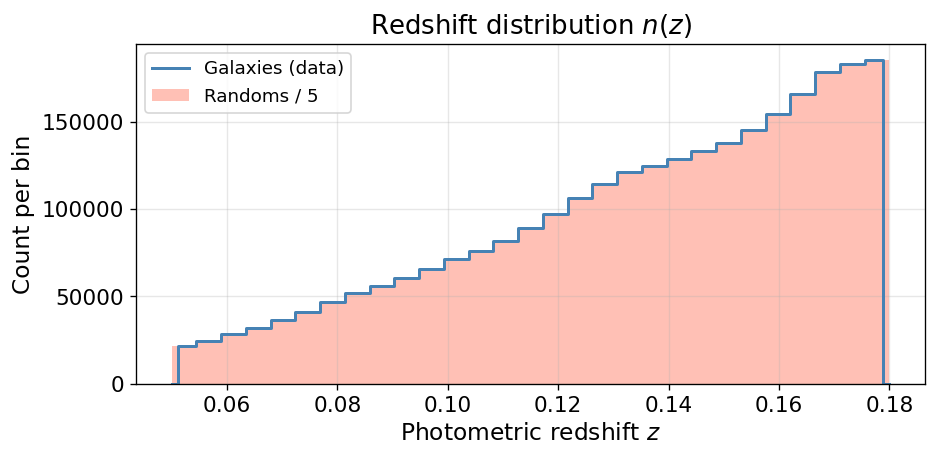

Mean redshift: z_mean = 0.135


In [3]:
z_bins = np.linspace(Z_MIN, Z_MAX, 30)
z_centres = 0.5 * (z_bins[:-1] + z_bins[1:])

nz_data, _ = np.histogram(z_g, bins=z_bins)
nz_rand, _ = np.histogram(rand_z[mask_rand], bins=z_bins)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(z_centres, nz_rand / 5, width=np.diff(z_bins), alpha=0.4, color='tomato',
       label='Randoms / 5')
ax.step(np.concatenate([z_bins[:1], z_centres, z_bins[-1:]]),
        np.concatenate([[0], nz_data, [0]]),
        where='mid', color='steelblue', linewidth=1.8, label='Galaxies (data)')
ax.set_xlabel('Photometric redshift $z$')
ax.set_ylabel('Count per bin')
ax.set_title('Redshift distribution $n(z)$')
ax.legend()
plt.tight_layout()
plt.show()

# Store the normalised n(z) for the Limber integral
nz_norm = nz_data / nz_data.sum()  # normalise to sum=1
dz = np.diff(z_bins)[0]
print(f'Mean redshift: z_mean = {np.sum(z_centres * nz_norm):.3f}')

---

## 4. Building the HEALPix galaxy map

### 4.1 What is HEALPix?

**HEALPix** (Hierarchical Equal Area isoLatitude PIXelization, Górski et al. 2005, ApJ 622, 759) divides the sphere into $N_{\rm pix} = 12\,N_{\rm side}^2$ pixels of **equal area** $\Omega_{\rm pix} = 4\pi/N_{\rm pix}$.

| $N_{\rm side}$ | $N_{\rm pix}$ | $\Omega_{\rm pix}$ [deg²] | $\theta_{\rm pix}$ |
|---------------|--------------|--------------------------|-------------------|
| 64 | 49,152 | 0.84 | ~55' |
| 128 | 196,608 | 0.21 | ~27' |
| 256 | 786,432 | 0.052 | ~14' |
| 512 | 3,145,728 | 0.013 | ~7' |
| 1024 | 12,582,912 | 0.0033 | ~3.5' |

### 4.2 Choosing $N_{\rm side}$

The choice of $N_{\rm side}$ sets the minimum angular scale we can probe: $\ell_{\rm max} \approx 2\,N_{\rm side}$ (Nyquist limit). We also need enough galaxies per pixel to avoid Poisson-dominated pixels.

With $N_{\rm gal} \approx 2.7\times10^6$ galaxies over $A \approx 16{,}800\,{\rm deg}^2$:
- Mean number density: $\bar{n} \approx 160\,{\rm gal/deg}^2$
- At $N_{\rm side}=512$ (pixel area $= 0.013\,{\rm deg}^2$): $\bar{n}_{\rm pix} \approx 2$ galaxies/pixel
- At $N_{\rm side}=256$ (pixel area $= 0.052\,{\rm deg}^2$): $\bar{n}_{\rm pix} \approx 8$ galaxies/pixel

We use $N_{\rm side}=512$ to access scales up to $\ell \sim 1000$, accepting that shot noise dominates at high $\ell$.

In [4]:
NSIDE = 512
N_PIX = hp.nside2npix(NSIDE)
OMEGA_PIX = hp.nside2pixarea(NSIDE)  # sr
OMEGA_PIX_DEG2 = hp.nside2pixarea(NSIDE, degrees=True)

print(f'HEALPix parameters:')
print(f'  Nside     = {NSIDE}')
print(f'  N_pix     = {N_PIX:,}')
print(f'  Omega_pix = {OMEGA_PIX_DEG2:.4f} deg²')
print(f'  ell_max   ~ {2*NSIDE} (Nyquist)')

# Pixelise galaxy catalog
pix_gal  = hp.ang2pix(NSIDE, ra_g,  dec_g,  lonlat=True)
pix_rand = hp.ang2pix(NSIDE, rand_ra_g, rand_dec_g, lonlat=True)

# Galaxy count map
n_map = np.zeros(N_PIX)
for p in pix_gal:
    n_map[p] += 1

print(f'\nGalaxy map statistics:')
n_nonzero = (n_map > 0).sum()
print(f'  Occupied pixels: {n_nonzero:,} / {N_PIX:,}')
print(f'  Mean galaxies per occupied pixel: {n_map[n_map>0].mean():.1f}')
print(f'  Max galaxies in one pixel: {int(n_map.max())}')

HEALPix parameters:
  Nside     = 512
  N_pix     = 3,145,728
  Omega_pix = 0.0131 deg²
  ell_max   ~ 1024 (Nyquist)



Galaxy map statistics:
  Occupied pixels: 1,014,793 / 3,145,728
  Mean galaxies per occupied pixel: 2.7
  Max galaxies in one pixel: 82


### 4.3 Building the survey mask

The survey **mask** identifies which pixels are part of the observed footprint. We build it from the random catalog: a pixel is considered "observed" if it contains at least one random point.

We also apply a **Galactic plane cut** ($|b| > 20°$) to remove regions with heavy dust extinction, and a **bright star mask** (automatic, since the randoms already encode this).

Survey mask statistics:
  Observed pixels : 1,325,591
  f_sky           : 0.4214 (42.14% of sky)
  Area            : 17,384 deg²
  Area            : 5.30 sr


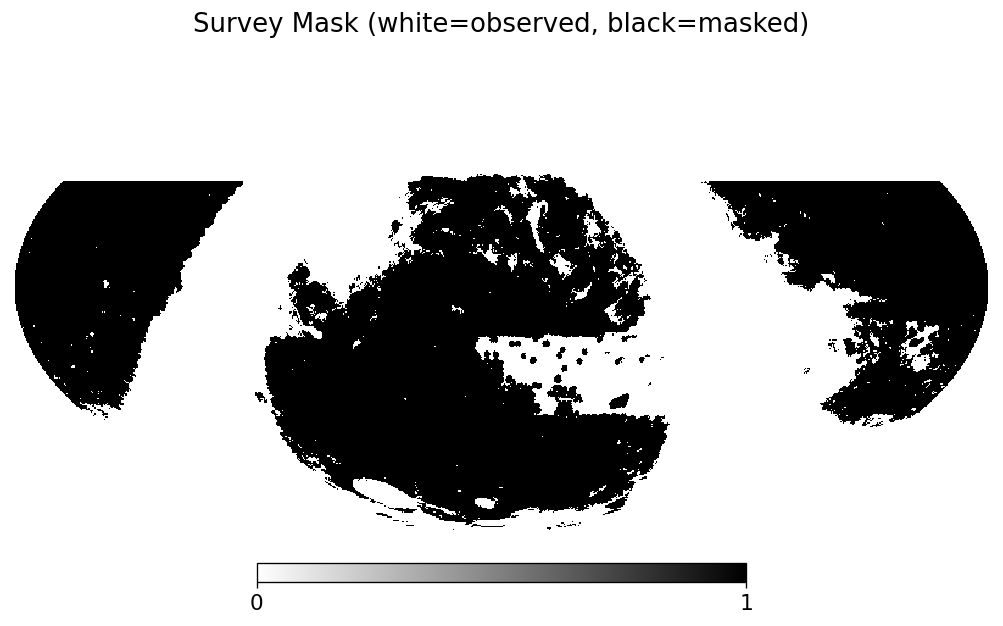

In [5]:
# Build mask from randoms
rand_map = np.zeros(N_PIX)
for p in pix_rand:
    rand_map[p] += 1

mask = (rand_map > 0).astype(np.float64)

# Survey statistics
f_sky = mask.sum() / N_PIX
area_deg2 = mask.sum() * OMEGA_PIX_DEG2
area_sr   = mask.sum() * OMEGA_PIX

print(f'Survey mask statistics:')
print(f'  Observed pixels : {int(mask.sum()):,}')
print(f'  f_sky           : {f_sky:.4f} ({f_sky*100:.2f}% of sky)')
print(f'  Area            : {area_deg2:,.0f} deg²')
print(f'  Area            : {area_sr:.2f} sr')

# Visualise the mask
hp.mollview(mask, title='Survey Mask (white=observed, black=masked)',
            cmap='gray_r', min=0, max=1)
plt.savefig('aps_healpix_mask.pdf', bbox_inches='tight')
plt.show()

### 4.4 Mask apodization

A **hard binary mask** has sharp edges that Fourier-transform into power at all angular scales, creating ringing artifacts that couple multipoles far from the true signal — a limitation the simple $f_{\rm sky}$ correction cannot fix.

**NaMaster's solution:** `nmt.mask_apodization()` applies a smooth taper at mask boundaries, reducing the support of the mask window function $W_\ell$ and consequently the off-diagonal mode-coupling.

Three apodization types are available (`apotype` parameter):
| Type | Formula at edge (distance $d$, scale $\sigma$) | Notes |
|------|-----------------------------------------------|-------|
| `"C1"` | $\sin^2(\pi d / 2\sigma)$ | Recommended — compact support |
| `"C2"` | Steeper cosine taper | Similar but narrower |
| `"smooth"` | Gaussian convolution | Longest taper, most effective |

The `aposize` parameter sets the apodization scale in degrees. It should be:
- Larger than the pixel scale (0.12° at $N_{\rm side}=512$)
- Smaller than the survey correlation length (~30°)

We use `aposize=0.5°` with `"C1"` apodization as the standard starting point. Note that apodization reduces $f_{\rm sky}^{\rm eff} = \langle w^2 \rangle < f_{\rm sky}^{\rm hard}$, slightly decreasing the effective survey area.

Apodizing mask (C1, 0.5 deg)...
Done in 0.2 s



Sky fraction comparison:
  f_sky (hard binary)   = 0.4214  (42.14%)
  f_sky_eff (apodized)  = 0.3911  (39.11%)
  Area loss from apod.  = 7.2%


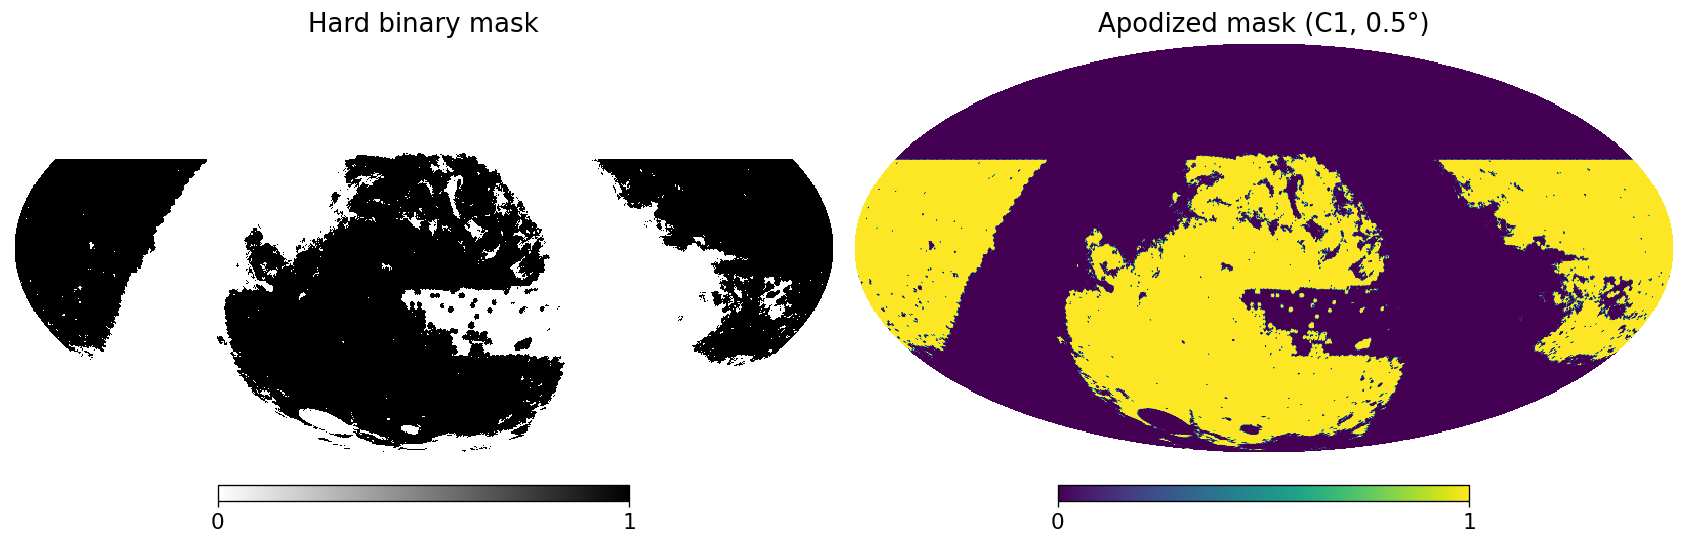

In [6]:
# Apodize the binary mask with C1 cosine taper, scale = 0.5 degrees
# This takes ~5-15 seconds at Nside=512
print('Apodizing mask (C1, 0.5 deg)...')
t0 = time.time()
mask_apo = nmt.mask_apodization(mask, aposize=0.5, apotype="C1")
print(f'Done in {time.time()-t0:.1f} s')

# Effective sky fraction: int w^2 d(Omega) / 4pi
f_sky_hard = mask.mean()
f_sky_eff  = (mask_apo**2).mean()

print(f'\nSky fraction comparison:')
print(f'  f_sky (hard binary)   = {f_sky_hard:.4f}  ({f_sky_hard*100:.2f}%)')
print(f'  f_sky_eff (apodized)  = {f_sky_eff:.4f}  ({f_sky_eff*100:.2f}%)')
print(f'  Area loss from apod.  = {(1 - f_sky_eff/f_sky_hard)*100:.1f}%')

# Visualise both masks side by side
fig = plt.figure(figsize=(14, 5))
hp.mollview(mask, title='Hard binary mask', cmap='gray_r',
            fig=fig.number, sub=(1, 2, 1), min=0, max=1)
hp.mollview(mask_apo, title='Apodized mask (C1, 0.5°)', cmap='viridis',
            fig=fig.number, sub=(1, 2, 2), min=0, max=1)
plt.savefig('aps_mask_apodization.pdf', bbox_inches='tight')
plt.show()

### 4.4 Building the galaxy overdensity map

The overdensity field is:

$$\delta_p = \frac{n_p}{\bar{n}} - 1$$

where $\bar{n} = N_{\rm gal} / N_{\rm pix,obs}$ is the mean galaxy count per observed pixel. Unobserved pixels are set to zero.

Overdensity map:
  Mean galaxy count per pixel : 2.06
  delta range                 : [-1.00, 38.74]
  Mean delta (should be ~0)   : 0.0000


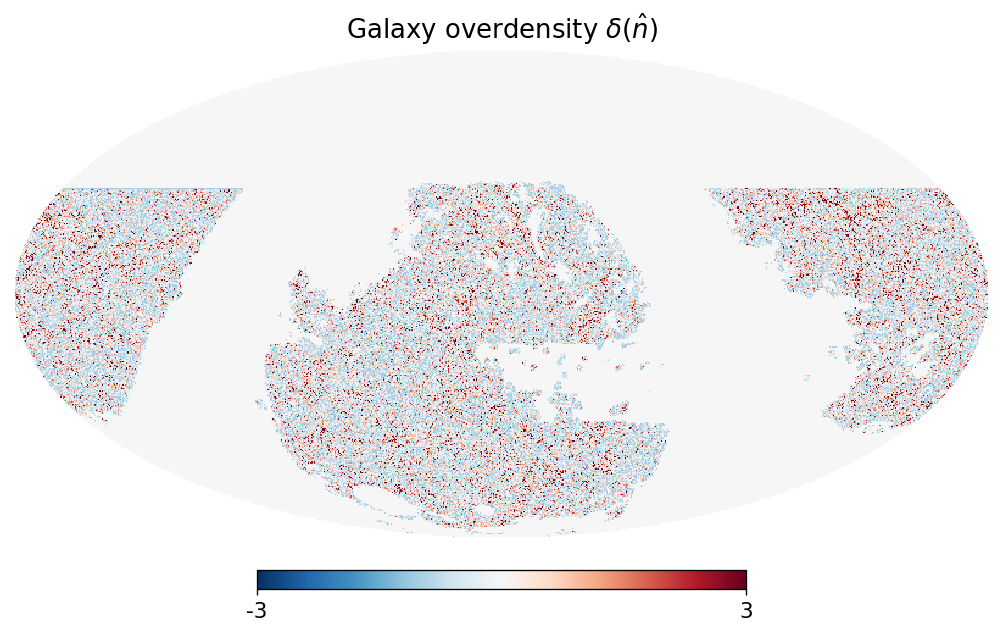

In [7]:
# Mean density
n_pix_obs = mask.sum()
n_gal_eff = n_map[mask > 0].sum()
n_bar = n_gal_eff / n_pix_obs

# Overdensity map
delta_map = np.zeros(N_PIX)
obs = mask > 0
delta_map[obs] = n_map[obs] / n_bar - 1.0
delta_map *= mask  # zero out unobserved pixels

print(f'Overdensity map:')
print(f'  Mean galaxy count per pixel : {n_bar:.2f}')
print(f'  delta range                 : [{delta_map[obs].min():.2f}, {delta_map[obs].max():.2f}]')
print(f'  Mean delta (should be ~0)   : {delta_map[obs].mean():.4f}')

# Visualise the overdensity
hp.mollview(delta_map, title=r'Galaxy overdensity $\delta(\hat{n})$',
            cmap='RdBu_r', min=-3, max=3)
plt.savefig('aps_overdensity_map.pdf', bbox_inches='tight')
plt.show()

---

## 5. Measuring the angular power spectrum

### 5.1 Reference: simple $f_{\rm sky}$ correction

We first compute $C_\ell$ with the simple approach (`sum_stat.powspec.angular_cl`) as a reference. This applies:
1. `healpy.anafast` on the masked overdensity map
2. Shot-noise subtraction: $N_\ell = \Omega_{\rm pix}/N_{\rm gal}$
3. $f_{\rm sky}$ MASTER correction: $C_\ell^{\rm corrected} = \tilde{C}_\ell / f_{\rm sky}$

The result (`cl_data_fsky`) is kept for comparison with the full NaMaster pipeline in Section 5.2.

**Multipole binning:** logarithmically spaced from $\ell_{\rm min}=10$ to $\ell_{\rm max}=2N_{\rm side}=1024$.

In [8]:
# Build the GalaxyCatalogue
cat = GalaxyCatalogue(
    ra       = ra_g,
    dec      = dec_g,
    redshift = z_g,
    weight   = np.ones(len(ra_g)),
)

# Multipole bin edges — logarithmically spaced
ell_edges = np.unique(np.round(np.logspace(np.log10(10), np.log10(1100), 22)).astype(int))
print(f'Multipole bin edges: {ell_edges}')

print('\nComputing angular power spectrum C_ell (simple f_sky method)...')
ell_eff, cl_data_fsky, nl_data, cov_data_fsky = cl_angular(
    gal                  = cat,
    nside                = NSIDE,
    ell_bins             = ell_edges,
    mask                 = mask,
    use_master_correction= True,   # apply f_sky correction
)
print('Done!')

cl_err_fsky = np.sqrt(np.diag(cov_data_fsky))
nl_val = nl_data[0]   # shot noise per steradian (same for all ell)

print(f'\nC_ell results (simple f_sky):')
print(f'{"ell_eff":>8s}  {"C_ell":>14s}  {"N_ell":>14s}  {"sigma":>12s}  {"S/N":>6s}')
for le, cl, nl, se in zip(ell_eff, cl_data_fsky, nl_data, cl_err_fsky):
    snr = cl/se if se > 0 else 0
    flag = '***' if cl < 0 else ''
    print(f'{le:8.1f}  {cl:14.3e}  {nl:14.3e}  {se:12.3e}  {snr:6.1f} {flag}')

Multipole bin edges: [  10   13   16   20   24   31   38   48   60   75   94  117  147  184
  230  287  359  449  562  703  879 1100]

Computing angular power spectrum C_ell (simple f_sky method)...


Done!

C_ell results (simple f_sky):
 ell_eff           C_ell           N_ell         sigma     S/N
    11.0       5.072e-04       1.936e-06     6.404e-04     0.8 
    14.0       2.977e-04       1.936e-06     3.769e-04     0.8 
    17.5       3.419e-04       1.936e-06     3.746e-04     0.9 
    21.5       3.029e-04       1.936e-06     3.321e-04     0.9 
    27.0       2.546e-04       1.936e-06     2.112e-04     1.2 
    34.0       1.858e-04       1.936e-06     1.545e-04     1.2 
    42.5       1.543e-04       1.936e-06     1.076e-04     1.4 
    53.5       1.050e-04       1.936e-06     6.728e-05     1.6 
    67.0       7.939e-05       1.936e-06     4.574e-05     1.7 
    84.0       5.670e-05       1.936e-06     2.931e-05     1.9 
   105.0       4.264e-05       1.936e-06     2.025e-05     2.1 
   131.5       3.390e-05       1.936e-06     1.425e-05     2.4 
   165.0       2.561e-05       1.936e-06     9.864e-06     2.6 
   206.5       1.939e-05       1.936e-06     6.851e-06     2.8 
   2

### 5.1a First look at the simple f_sky power spectrum

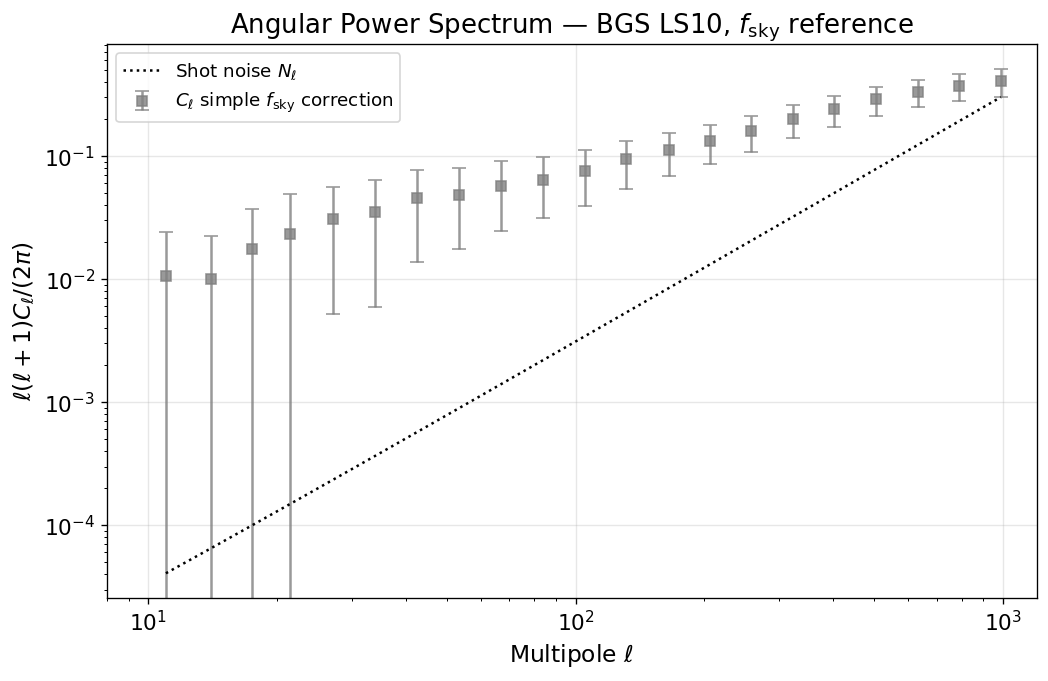

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

norm = ell_eff * (ell_eff + 1) / (2 * np.pi)

good = cl_data_fsky > 0
ax.errorbar(ell_eff[good], (norm * cl_data_fsky)[good], yerr=(norm * cl_err_fsky)[good],
            fmt='s', color='gray', ms=6, capsize=4, alpha=0.8,
            label=r'$C_\ell$ simple $f_{\rm sky}$ correction')

ax.plot(ell_eff, norm * nl_data, 'k:', lw=1.5, label='Shot noise $N_\\ell$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'Multipole $\ell$', fontsize=14)
ax.set_ylabel(r'$\ell(\ell+1)C_\ell / (2\pi)$', fontsize=14)
ax.set_title(r'Angular Power Spectrum — BGS LS10, $f_{\rm sky}$ reference')
ax.legend()
ax.set_xlim(8, 1200)

plt.savefig('aps_cl_fsky_reference.pdf', bbox_inches='tight')
plt.show()

---

## 5.2 Full NaMaster pipeline

### 5.2.1 NaMaster field and bandpower binning

`nmt.NmtField` wraps the signal map + mask into an object that encodes the sky geometry. For spin-0 galaxy clustering, a single overdensity map is passed. The `n_iter` parameter controls the number of `healpy.map2alm` power iterations for accurate spherical harmonic transforms; `n_iter=3` (default) is more accurate but slower.

`nmt.NmtBin.from_nside_linear` creates linear-width multipole bins of width 20 — a good choice for $N_{\rm side}=512$ that balances multipole resolution and signal-to-noise per band.

In [10]:
# NaMaster spin-0 field (galaxy overdensity, apodized mask)
print('Building NmtField (apodized mask, n_iter=3)...')
t0 = time.time()
f_nmt = nmt.NmtField(mask_apo, [delta_map])
print(f'NmtField ready in {time.time()-t0:.1f} s')

# Linear bandpower binning: width=20 multipoles per band
b = nmt.NmtBin.from_nside_linear(NSIDE, 20)
ell_nmt = b.get_effective_ells()

print(f'\nNaMaster bandpower binning:')
print(f'  N_bands   = {b.get_n_bands()}')
print(f'  ell range = [{ell_nmt[0]:.0f}, {ell_nmt[-1]:.0f}]')
print(f'  ell_eff (first 10): {np.round(ell_nmt[:10]).astype(int)}')

Building NmtField (apodized mask, n_iter=3)...


NmtField ready in 0.5 s

NaMaster bandpower binning:
  N_bands   = 76
  ell range = [12, 1512]
  ell_eff (first 10): [ 12  32  52  72  92 112 132 152 172 192]


### 5.2.2 Mode-coupling matrix and NmtWorkspace

The core of the MASTER algorithm is computing the mode-coupling matrix $M_{\ell\ell'}$, which encodes how the survey mask mixes power between multipoles. `NmtWorkspace` stores this matrix and its pseudo-inverse for efficient decoupling.

**Key difference from the $f_{\rm sky}$ approximation:**
- $f_{\rm sky}$ assumes $M_{\ell\ell'} = f_{\rm sky}\,\delta_{\ell\ell'}$ (diagonal)
- NaMaster computes the full matrix from $\tilde{W}_\ell = \sum_m |a_{\ell m}^w|^2/(2\ell+1)$ (mask power spectrum)
- At $f_{\rm sky} \sim 0.4$, the off-diagonal elements can bias low-$\ell$ estimates by 5–20%

**Disk caching:** The workspace computation takes 2–8 minutes at $N_{\rm side}=512$. We save it to disk so subsequent runs load instantly.

In [11]:
WS_FILE = f'aps_nmt_workspace_nside{NSIDE}.fits'
w = nmt.NmtWorkspace()

if os.path.exists(WS_FILE):
    print(f'Loading cached workspace from {WS_FILE}...')
    w.read_from(WS_FILE)
    print('Loaded.')
else:
    print('Computing mode-coupling matrix (~2-8 min at Nside=512)...')
    t0 = time.time()
    w.compute_coupling_matrix(f_nmt, f_nmt, b)
    elapsed = time.time() - t0
    w.write_to(WS_FILE)
    print(f'Done in {elapsed:.0f} s. Saved to {WS_FILE}')

# Compute the coupled pseudo-Cl and decouple via the MCM
cl_coupled = nmt.compute_coupled_cell(f_nmt, f_nmt)   # shape (1, n_ell_full)
cl_nmt     = w.decouple_cell(cl_coupled)[0]            # shape (n_bands,), includes shot noise

# Shot noise level (same value as the f_sky pipeline)
cl_nmt_sn  = cl_nmt - nl_val                           # shot-noise subtracted

norm_nmt = ell_nmt * (ell_nmt + 1) / (2 * np.pi)
print(f'\nNaMaster C_ell (shot-noise subtracted), first 10 bands:')
print(f'{"ell_eff":>8s}  {"C_ell (NaMaster)":>18s}  {"C_ell (f_sky)":>16s}  {"ratio":>7s}')
cl_fsky_interp = np.interp(ell_nmt, ell_eff, cl_data_fsky)
for le, cn, cf in zip(ell_nmt[:10], cl_nmt_sn[:10], cl_fsky_interp[:10]):
    ratio = cn/cf if abs(cf) > 1e-20 else float('nan')
    print(f'{le:8.1f}  {cn:18.3e}  {cf:16.3e}  {ratio:7.3f}')

Loading cached workspace from aps_nmt_workspace_nside512.fits...
Loaded.

NaMaster C_ell (shot-noise subtracted), first 10 bands:
 ell_eff    C_ell (NaMaster)     C_ell (f_sky)    ratio
    11.5           7.404e-04         4.723e-04    1.568
    31.5           2.047e-04         2.103e-04    0.973
    51.5           1.255e-04         1.140e-04    1.101
    71.5           7.242e-05         7.338e-05    0.987
    91.5           4.938e-05         5.168e-05    0.955
   111.5           3.961e-05         4.049e-05    0.978
   131.5           3.496e-05         3.390e-05    1.031
   151.5           2.820e-05         2.895e-05    0.974
   171.5           2.517e-05         2.463e-05    1.022
   191.5           2.119e-05         2.164e-05    0.979


### 5.2.3 Bandpower window functions

The bandpower window functions $W_{b\ell}$ answer: "which raw multipoles $\ell$ contribute to band $b$?"

They are the rows of the decoupled mode-coupling matrix and are essential for an **unbiased theory comparison**. Instead of evaluating the theory at a single effective $\ell$, one computes:

$$C_b^{\rm theory} = \sum_\ell W_{b\ell}\,C_\ell^{\rm theory, raw}$$

A perfectly localised window function would be a delta-function at $\ell_{\rm eff}[b]$. In practice, the mask broadens the windows — narrower windows indicate a cleaner footprint.

Bandpower window shape: (1, 76, 1, 1536)
win_2d shape: (76, 1536)  (n_bands=76, n_ell=1536)


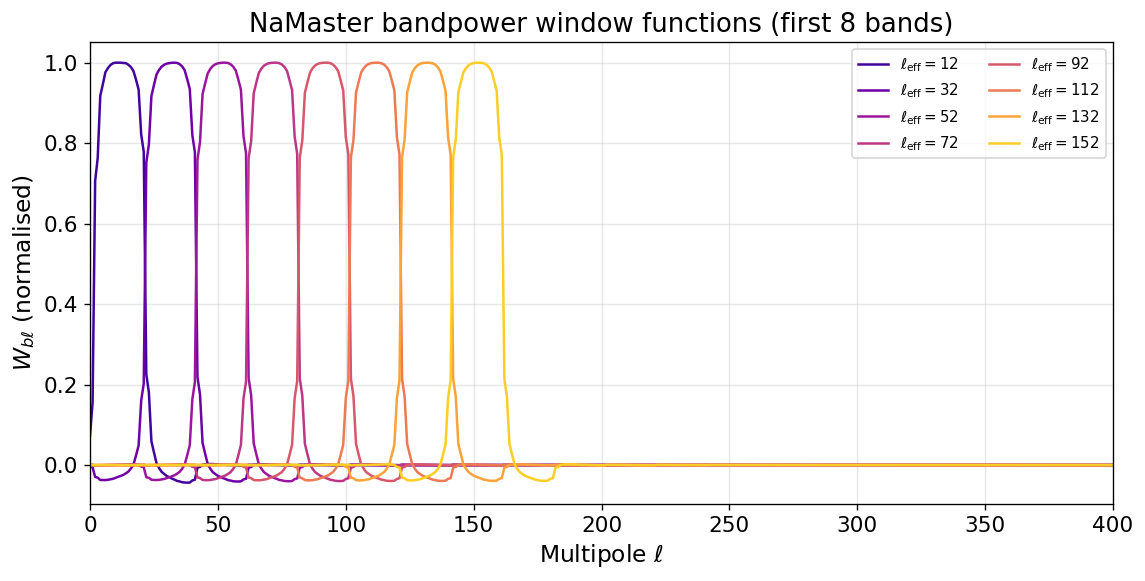


Note: windows peak near ell_eff but have extended wings from mode-coupling.
Use these windows when comparing theory to data (Section 6).


In [12]:
bpw_win = w.get_bandpower_windows()
print(f'Bandpower window shape: {bpw_win.shape}')

# Extract win_2d of shape (n_bands, n_ell_full) from whatever shape pymaster returns.
# pymaster 2.x returns (n_cls, n_bands, n_cls, n_ell_full), e.g. (1, 76, 1, 1536)
# pymaster 1.x returns (n_cls_tot, n_bands, n_ell_full)
n_bands = b.get_n_bands()
if bpw_win.ndim == 4:
    if bpw_win.shape[1] == n_bands:          # (n_cls, n_bands, n_cls, n_ell_full)
        win_2d = bpw_win[0, :, 0, :]
    else:                                    # (n_bands, n_cls, n_cls, n_ell_full)
        win_2d = bpw_win[:, 0, 0, :]
elif bpw_win.ndim == 3:                      # (n_cls_tot, n_bands, n_ell_full)
    win_2d = bpw_win[0, :, :]
else:
    raise ValueError(f'Unexpected bpw_win shape: {bpw_win.shape}')
print(f'win_2d shape: {win_2d.shape}  (n_bands={n_bands}, n_ell={win_2d.shape[-1]})')

n_bands_plot = min(8, n_bands)
ell_full = np.arange(win_2d.shape[-1])

fig, ax = plt.subplots(figsize=(11, 5))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, n_bands_plot))
for i in range(n_bands_plot):
    win = win_2d[i, :]
    ax.plot(ell_full, win / win.max(),
            color=colors[i], label=f'$\\ell_{{\\rm eff}}={ell_nmt[i]:.0f}$')

ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$W_{b\ell}$ (normalised)')
ax.set_title('NaMaster bandpower window functions (first 8 bands)')
ax.set_xlim(0, min(400, ell_full[-1]))
ax.legend(fontsize=9, ncol=2)
plt.savefig('aps_bpw_windows.pdf', bbox_inches='tight')
plt.show()

print('\nNote: windows peak near ell_eff but have extended wings from mode-coupling.')
print('Use these windows when comparing theory to data (Section 6).')


### 5.2.4 Dust template deprojection

**The problem:** Dust extinction ($E(B-V)$) correlates with galaxy completeness — in dusty regions, faint galaxies are missed. This spurious correlation between dust and galaxy density produces false power at large angular scales.

**NaMaster's solution:** Pass the dust map as a `template` to `NmtField`. NaMaster fits and removes the best-fit linear component $\delta^{\rm deprojected}(\hat{n}) = \delta(\hat{n}) - \hat{\alpha}\,s(\hat{n})$ analytically before computing the pseudo-$C_\ell$.

The cost is a small **deprojection bias** — power genuinely correlated with $E(B-V)$ is also removed. But this is usually preferable to the systematic error.

We build the dust template from the random catalog (smoother than the data because randoms uniformly sample the survey footprint):

$$\overline{E(B-V)}_p^{\rm rand} = \frac{\sum_{i \in {\rm rand}, p} E(B-V)_i}{N_p^{\rm rand}}$$

Dust template (E(B-V) from randoms):
  Mean EBV (in footprint) = 0.0431
  Max  EBV                = 0.1000


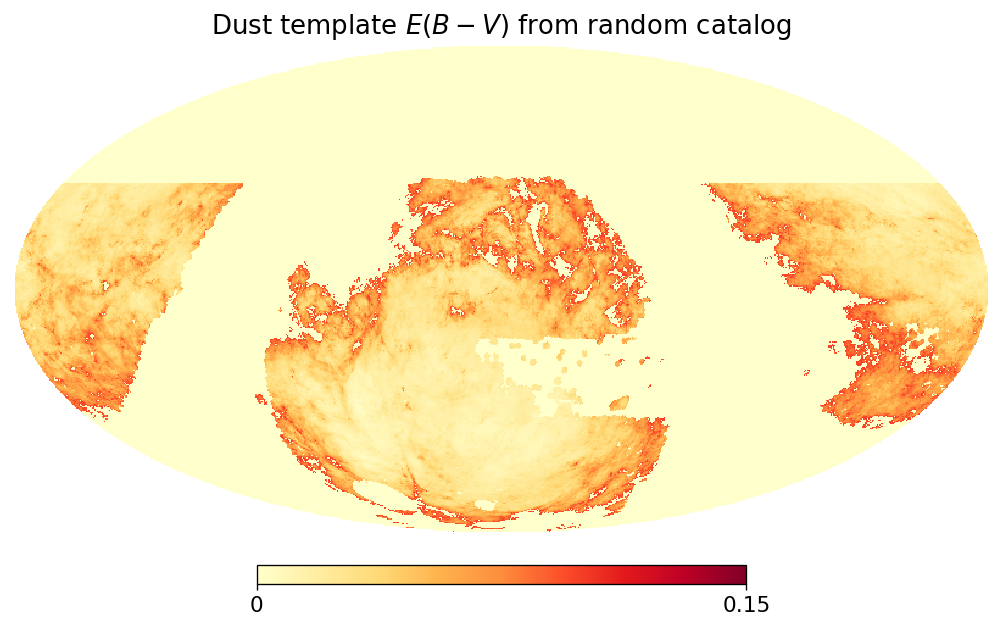

In [13]:
# Build the dust template map from the random catalog
pix_rand_all = hp.ang2pix(NSIDE, rand_ra_g, rand_dec_g, lonlat=True)
ebv_rand_map  = np.zeros(N_PIX)
rand_count    = np.zeros(N_PIX)

for p, e in zip(pix_rand_all, rand_ebv_g):
    ebv_rand_map[p] += e
    rand_count[p]   += 1

# Mean EBV per pixel (avoid division by zero)
with np.errstate(invalid='ignore'):
    ebv_rand_map = np.where(rand_count > 0, ebv_rand_map / rand_count, 0.0)
ebv_rand_map *= mask   # zero outside footprint

print(f'Dust template (E(B-V) from randoms):')
print(f'  Mean EBV (in footprint) = {ebv_rand_map[mask > 0].mean():.4f}')
print(f'  Max  EBV                = {ebv_rand_map.max():.4f}')

# Visualise
hp.mollview(ebv_rand_map, title='Dust template $E(B-V)$ from random catalog',
            cmap='YlOrRd', min=0, max=0.15)
plt.savefig('aps_ebv_template.pdf', bbox_inches='tight')
plt.show()

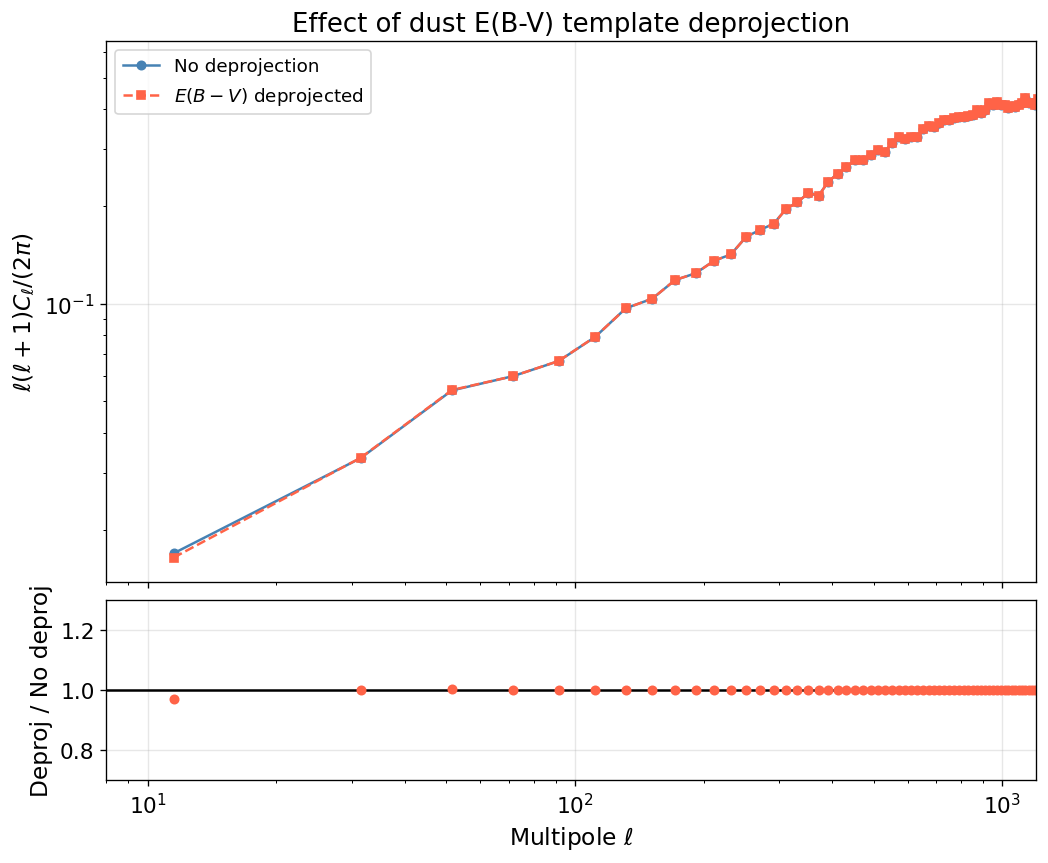

Large deviations at low ell indicate significant dust-galaxy correlation.
Small deviations indicate dust is not a major systematic for this sample.


In [14]:
# NmtField with dust template deprojection
# templates=[[template_map]] : one template per spin-0 map component
f_deproj = nmt.NmtField(mask_apo, [delta_map], templates=[[ebv_rand_map]])

# Compute coupled Cl and decouple using the same workspace w
cl_coupled_deproj = nmt.compute_coupled_cell(f_deproj, f_deproj)
cl_nmt_deproj     = w.decouple_cell(cl_coupled_deproj)[0] - nl_val

# Compare with and without deprojection
good_n = cl_nmt_sn > 0
good_d = cl_nmt_deproj > 0

fig, axes = plt.subplots(2, 1, figsize=(10, 8),
                          gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05},
                          sharex=True)
ax = axes[0]
ax.plot(ell_nmt[good_n], (norm_nmt * cl_nmt_sn)[good_n],
        'o-', color='steelblue', ms=5, label='No deprojection')
ax.plot(ell_nmt[good_d], (norm_nmt * cl_nmt_deproj)[good_d],
        's--', color='tomato', ms=5, label=r'$E(B-V)$ deprojected')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel(r'$\ell(\ell+1)C_\ell/(2\pi)$')
ax.set_title('Effect of dust E(B-V) template deprojection')
ax.legend()

ax2 = axes[1]
both = good_n & good_d
ax2.axhline(1.0, color='k', lw=1.5)
ax2.plot(ell_nmt[both], cl_nmt_deproj[both] / cl_nmt_sn[both],
         'o', color='tomato', ms=5)
ax2.set_ylabel('Deproj / No deproj')
ax2.set_xlabel(r'Multipole $\ell$')
ax2.set_ylim(0.7, 1.3)
ax2.set_xlim(8, 1200)
plt.savefig('aps_cl_deprojection.pdf', bbox_inches='tight')
plt.show()

print('Large deviations at low ell indicate significant dust-galaxy correlation.')
print('Small deviations indicate dust is not a major systematic for this sample.')

### 5.2.5 Gaussian analytical covariance (NaMaster)

The simple diagonal covariance formula $\mathrm{Var}(C_b) \approx 2(C_b + N_b)^2 / [(2\ell+1)\,f_{\rm sky}\,\Delta\ell]$ is approximate. NaMaster computes the exact Gaussian covariance including:

1. **Off-diagonal mode coupling** from the mask (captured in `NmtCovarianceWorkspace`)
2. **All four legs** of the Gaussian connected trispectrum: $\mathrm{Cov}(C_{b_1}, C_{b_2}) = f(C_{b_1b_2}^{TT}, C_{b_1b_2}^{TT})$

For a galaxy auto-spectrum (spin-0), the four input spectra are all the same total (signal+noise) $C_\ell$.

Reference: Alonso et al. 2019, MNRAS 484, §4; García-García et al. 2019, JCAP.

In [15]:
CW_FILE = f'aps_nmt_covworkspace_nside{NSIDE}.fits'
cw = nmt.NmtCovarianceWorkspace()

if os.path.exists(CW_FILE):
    print(f'Loading cached covariance workspace from {CW_FILE}...')
    cw.read_from(CW_FILE)
    print('Loaded.')
else:
    print('Computing covariance coupling coefficients (~1-4 min at Nside=512)...')
    t0 = time.time()
    cw.compute_coupling_coefficients(f_nmt, f_nmt)
    elapsed = time.time() - t0
    cw.write_to(CW_FILE)
    print(f'Done in {elapsed:.0f} s. Saved to {CW_FILE}')

# gaussian_covariance requires full-ell coupled C_ell of length lmax+1,
# not the decoupled bandpowers. Use cl_coupled[0] (shape: n_ell_full).
# Spins are all 0 for galaxy auto-spectrum.
cov_nmt = nmt.gaussian_covariance(
    cw,
    0, 0, 0, 0,            # spins of fields a1, a2, b1, b2
    [cl_coupled[0]],       # coupled C_ell a1-b1 (length lmax+1, signal+noise)
    [cl_coupled[0]],       # coupled C_ell a1-b2
    [cl_coupled[0]],       # coupled C_ell a2-b1
    [cl_coupled[0]],       # coupled C_ell a2-b2
    wa=w, wb=w,            # MCM workspaces
)
cl_err_nmt = np.sqrt(np.diag(cov_nmt))

print(f'Covariance matrix shape: {cov_nmt.shape}')
print(f'Fractional errors (NaMaster vs simple f_sky):')
print(f'{"ell_eff":>8s}  {"sigma/C (NaMaster)":>20s}  {"sigma/C (f_sky)":>18s}')
cl_fsky_interp2 = np.interp(ell_nmt, ell_eff, cl_data_fsky)
cl_err_fsky_interp = np.interp(ell_nmt, ell_eff, cl_err_fsky)
for le, cn, en, cf, ef in zip(ell_nmt[:12], cl_nmt_sn[:12], cl_err_nmt[:12],
                               cl_fsky_interp2[:12], cl_err_fsky_interp[:12]):
    if abs(cn) > 0 and abs(cf) > 0:
        print(f'{le:8.1f}  {en/abs(cn):20.3f}  {ef/abs(cf):18.3f}')


Loading cached covariance workspace from aps_nmt_covworkspace_nside512.fits...
Loaded.
Covariance matrix shape: (76, 76)
Fractional errors (NaMaster vs simple f_sky):
 ell_eff    sigma/C (NaMaster)     sigma/C (f_sky)
    11.5                 0.070               1.263
    31.5                 0.032               0.831
    51.5                 0.022               0.655
    71.5                 0.019               0.564
    91.5                 0.017               0.504
   111.5                 0.015               0.464
   131.5                 0.014               0.420
   151.5                 0.013               0.402
   171.5                 0.012               0.381
   191.5                 0.012               0.367
   211.5                 0.012               0.351
   231.5                 0.011               0.342


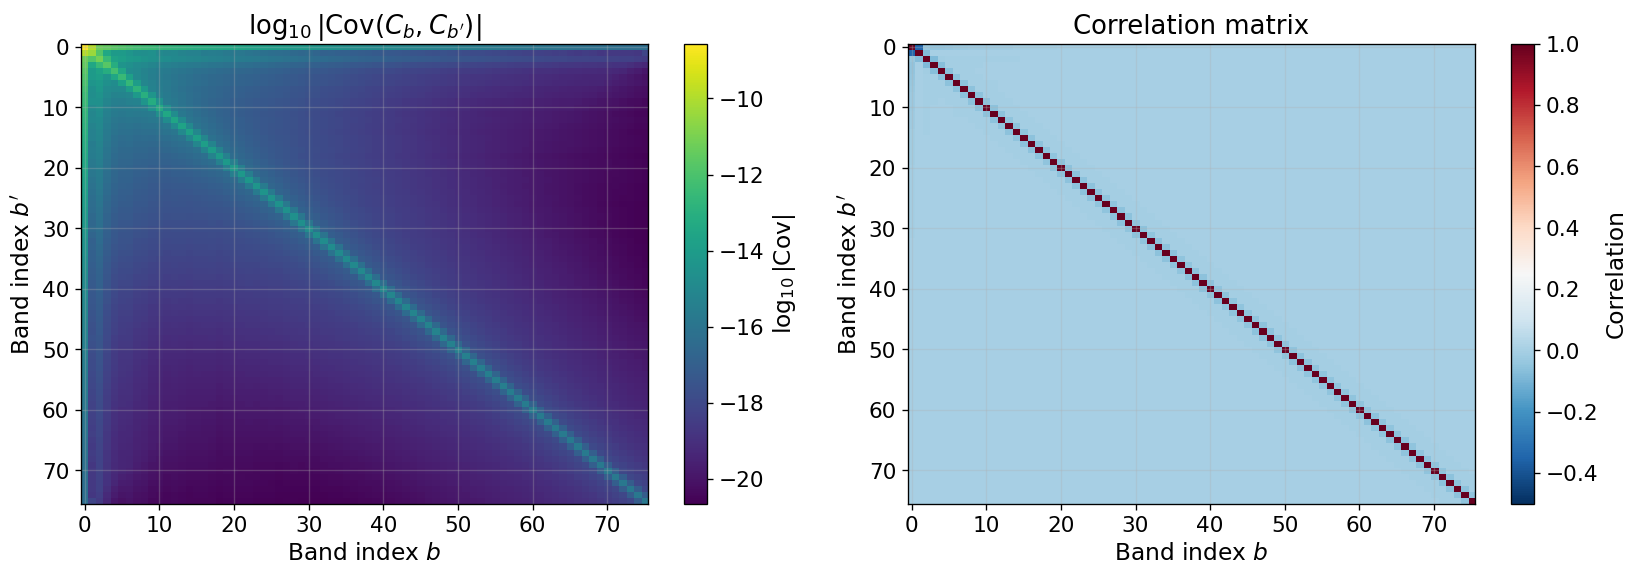

In [16]:
# Visualise the covariance matrix
diag = np.sqrt(np.diag(cov_nmt))
corr_nmt = cov_nmt / np.outer(diag, diag)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(np.log10(np.abs(cov_nmt) + 1e-40), aspect='auto', cmap='viridis')
axes[0].set_title(r'$\log_{10}|\mathrm{Cov}(C_b, C_{b^\prime})|$')
plt.colorbar(im0, ax=axes[0], label=r'$\log_{10}|\mathrm{Cov}|$')

im1 = axes[1].imshow(corr_nmt, aspect='auto', cmap='RdBu_r', vmin=-0.5, vmax=1.0)
axes[1].set_title('Correlation matrix')
plt.colorbar(im1, ax=axes[1], label='Correlation')

for ax in axes:
    ax.set_xlabel('Band index $b$')
    ax.set_ylabel("Band index $b'$")

plt.tight_layout()
plt.savefig('aps_cov_matrix.pdf', bbox_inches='tight')
plt.show()

### 5.2.6 Integral constraint

When we measure $C_\ell$ from a finite survey of area $\Omega_{\rm survey}$, we estimate the mean galaxy density $\bar{n}$ from the same survey. This normalization removes the $\ell=0$ monopole and suppresses power at scales comparable to the survey size — the **integral constraint** (IC).

The IC adds a constant offset to the measured $C_\ell$ (Bernstein 1994, ApJ 424, 569):

$$C_\ell^{\rm IC} = \frac{\left[\sum_\ell (2\ell+1)\,\tilde{W}_\ell\right]^2}{\sum_\ell (2\ell+1)\,\tilde{W}_\ell^2 / C_\ell^{\rm true}}$$

where $\tilde{W}_\ell$ is the mask power spectrum. For large surveys ($f_{\rm sky} \gtrsim 0.1$), $C^{\rm IC} \ll C_\ell$ at all but the lowest multipoles. For sub-1000 deg² surveys, the IC can be significant at $\ell < 20$.

Integral constraint:
  C_IC           = 4.837e-14 sr
  C_ell at ell~12 = 7.404e-04 sr
  IC / C_ell     = 0.0000 (0.00%)

=> IC is < 1% of signal: NEGLIGIBLE for this large survey.


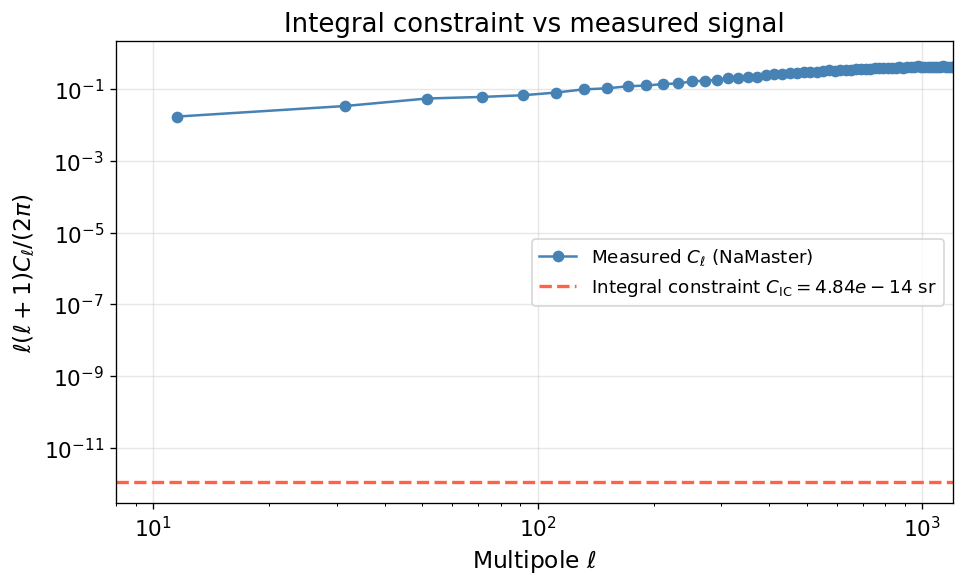

In [17]:
# Integral constraint correction (Bernstein 1994)
lmax_ic = 3 * NSIDE
w_ell = hp.anafast(mask, lmax=lmax_ic)   # mask power spectrum W_ell
ell_ic = np.arange(len(w_ell))

# An approximate "true" C_ell from the f_sky-corrected full-ell spectrum
cl_full_approx = hp.anafast(delta_map * mask, lmax=lmax_ic) / f_sky_hard
cl_full_approx = np.maximum(cl_full_approx, 1e-30)   # avoid division by zero

weight = (2 * ell_ic + 1) * w_ell
sum_w    = weight.sum()
sum_w2_c = np.sum(weight**2 / cl_full_approx)

c_ic = sum_w**2 / sum_w2_c   # IC in steradians

# Compare to signal at lowest measured band
c_signal_low_ell = np.abs(cl_nmt_sn[cl_nmt_sn != 0][0])
ic_fraction = c_ic / c_signal_low_ell if c_signal_low_ell > 0 else float('nan')

print(f'Integral constraint:')
print(f'  C_IC           = {c_ic:.3e} sr')
print(f'  C_ell at ell~{ell_nmt[0]:.0f} = {c_signal_low_ell:.3e} sr')
print(f'  IC / C_ell     = {ic_fraction:.4f} ({ic_fraction*100:.2f}%)')
print()
if ic_fraction < 0.01:
    print('=> IC is < 1% of signal: NEGLIGIBLE for this large survey.')
elif ic_fraction < 0.05:
    print('=> IC is 1-5% of signal: small but worth monitoring.')
else:
    print('=> IC is > 5% of signal: apply the correction!')

# Visualise IC vs signal
fig, ax = plt.subplots(figsize=(9, 5))
norm_ic = ell_nmt * (ell_nmt + 1) / (2 * np.pi)
ax.plot(ell_nmt[good_n], (norm_ic * cl_nmt_sn)[good_n],
        'o-', color='steelblue', label=r'Measured $C_\ell$ (NaMaster)')
# IC is a constant offset, shown at ell_nmt[0] for reference
ax.axhline(c_ic * ell_nmt[0] * (ell_nmt[0]+1)/(2*np.pi),
           ls='--', color='tomato', lw=2,
           label=f'Integral constraint $C_{{\\rm IC}} = {c_ic:.2e}$ sr')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$\ell(\ell+1)C_\ell/(2\pi)$')
ax.set_title('Integral constraint vs measured signal')
ax.legend()
ax.set_xlim(8, 1200)
plt.savefig('aps_integral_constraint.pdf', bbox_inches='tight')
plt.show()

---

## 6. Theoretical prediction: More+2015 HOD with BGS MAP parameters

### 6.1 The More+2015 HOD model

More et al. (2015, ApJ 806, 2; arXiv:1211.6211) extended the standard Zheng+2007 HOD by adding an **incompleteness function** $f_{\rm inc}(M)$, which accounts for the fact that the galaxy selection at a fixed stellar mass limit is not a perfect step function — some low-mass halos above the mass threshold are missed due to photometric scatter and stellar mass estimation uncertainties.

**Central galaxy occupation** (Eq. 1 of More et al. 2015):
$$\langle N_c \rangle(M) = f_{\rm inc}(M) \times \frac{1}{2}\left[1 + {\rm erf}\!\left(\frac{\log_{10}M - \log_{10}M_{\rm min}}{\sigma_{\log M}}\right)\right]$$

**Incompleteness function** (suppresses occupation of low-mass halos):
$$f_{\rm inc}(M) = 1 - \alpha_{\rm inc}\,\exp\!\left[-\left(\frac{M}{M_{\rm inc}}\right)^2\right]$$

**Satellite galaxy occupation** (power law, only for $M > \kappa M_{\rm min}$):
$$\langle N_s \rangle(M) = f_{\rm inc}(M)\,\langle N_c \rangle(M)\,\left(\frac{M - \kappa M_{\rm min}}{M_1}\right)^\alpha$$

and $\langle N_s \rangle = 0$ for $M \le \kappa M_{\rm min}$.

### 6.2 BGS best-fit MAP parameters (Comparat et al. 2025)

The parameters below come from fitting the projected correlation function $w_p(r_p)$ of the BGS LS10 sample ($\log_{10}M_* > 10$, $0.05 < z < 0.18$, $\pi_{\rm max} = 100$ Mpc/$h$) using the More+2015 full halo model (1-halo + 2-halo terms) with NFW satellite profiles and off-centring. The MAP fit has $\chi^2/{\rm ndof} = 1.3/12$.

| Parameter | MAP value | Physical meaning |
|-----------|-----------|-----------------|
| $\log_{10}M_{\rm min}$ | 11.385 | Min. halo mass for central galaxy occupation |
| $\sigma_{\log M}$ | 0.720 | Scatter in the central step function |
| $\log_{10}M_1$ | 12.835 | Satellite power-law mass normalization |
| $\alpha$ | 1.058 | Satellite power-law slope |
| $\kappa$ | 1.245 | Satellite threshold multiplier |
| $\alpha_{\rm inc}$ | 0.460 | Incompleteness amplitude |
| $\log_{10}M_{\rm inc}$ | 12.768 | Incompleteness pivot mass |
| $f_{\rm off}$ | 0.202 | Off-centring fraction (not used for $C_\ell$) |
| $\sigma_{\rm off}$ | 0.185 | Off-centring scale (not used for $C_\ell$) |

Cosmology: Planck 2018 ($h=0.6736$, $\Omega_m=0.3153$, $z_{\rm eff}=0.136$).

At $z_{\rm eff} = 0.136$ this gives:
- **Effective bias:** $b_{\rm eff} = 1.150$
- **Mean halo mass:** $M_{\rm eff} = 2.86 \times 10^{13}\,M_\odot/h$
- **Galaxy number density:** $n_{\rm gal} = 1.41 \times 10^{-2}\,h^3\,{\rm Mpc}^{-3}$

### 6.3 Limber approximation (2-halo term)

We compute the **2-halo** angular power spectrum via the Limber approximation:

$$C_\ell = b_{\rm eff}^2 \int dz\,\frac{H(z)}{c}\,\left[\frac{p(z)}{\chi(z)}\right]^2 P_{\rm lin}\!\left(\frac{\ell+0.5}{\chi(z)},\,z\right)$$

where $p(z) = dn/dz$ is the normalised galaxy redshift distribution and $\chi(z)$ is the comoving distance in **Mpc** (physical units from astropy).

**Unit conversion:** The linear power spectrum $P_{\rm lin}$ is tabulated in $(h/{\rm Mpc})^{-3}$ on a $k$ grid in $h/{\rm Mpc}$. The Limber wavenumber is $k = (\ell+0.5)/\chi$ in ${\rm Mpc}^{-1}$. To convert:
$$k\,[h/\rm Mpc] = k\,[{\rm Mpc}^{-1}] / h$$
because $1\,h/{\rm Mpc} = h\,{\rm Mpc}^{-1}$, so $1\,{\rm Mpc}^{-1} = (1/h)\,h/{\rm Mpc}$.

**At small scales** ($\ell > 400$, corresponding to $r_p < 3$ Mpc/$h$), the 1-halo term (satellite–satellite pairs within the same halo) adds power above the 2-halo prediction. The theory curve shown is **2-halo only**.

### 6.4 Bandpower window functions

Rather than evaluating the theory at a single effective $\ell$, we apply the **bandpower window functions** $W_{b\ell}$ from the NaMaster workspace:
$$C_b^{\rm theory} = \sum_\ell W_{b\ell}\,C_\ell^{\rm Limber}$$
This accounts for the smearing of power across multipoles caused by the survey window.

In [18]:
MAP_FILE = ('/home/comparat/software/hod_mod/results/bgs_comparat2025/'
            'mstar10.0_wp_more2015_nfw_rp100_offcen_inc/map_result.json')

with open(MAP_FILE) as fh:
    map_result = json.load(fh)

params = map_result['params']

# HOD parameters (More+2015, without off-centering — used for 2h only)
hod_params_more = {
    'log10mmin':  params['log10mmin'],
    'sigma_logm': params['sigma_logm'],
    'log10m1':    params['log10m1'],
    'alpha':      params['alpha'],
    'kappa':      params['kappa'],
    'alpha_inc':  params['alpha_inc'],
    'log10m_inc': params['log10m_inc'],
}
# Full HOD params including off-centring (for FullHaloModelPrediction)
hod_params_full = {
    **hod_params_more,
    'f_off':     params['f_off'],
    'sigma_off': params['sigma_off'],
}

# Cosmology from MAP result (Planck 2018)
theta_cosmo_map = {
    'h':              params['h'],
    'Omega_m':        params['Omega_m'],
    'Omega_b':        0.0493,
    'Omega_cdm':      params['Omega_m'] - 0.0493,
    'n_s':            params['n_s'],
    'ln10^{10}A_s':   params['ln10^{10}A_s'],
    'w0': -1.0, 'wa': 0.0,
}

cosmo_map = FlatLambdaCDM(H0=params['h'] * 100, Om0=params['Omega_m'])
z_eff_map = float(map_result['z_eff'])

print(f'Loaded MAP result (chi2/ndof = {map_result["chi2"]:.3f}/{map_result["ndof"]})')
print(f'Cosmology: h={params["h"]}, Omega_m={params["Omega_m"]}')
print(f'z_eff = {z_eff_map}')
print(f'\nHOD parameters (More+2015):')
for k, v in hod_params_more.items():
    print(f'  {k:15s} = {v:.4f}')

# Initialise power spectrum and halo mass function
print('\nSetting up LinearPowerSpectrum (CAMB) and HaloMassFunction (Tinker 2008)...')
pk_lin = LinearPowerSpectrum()
hmf    = HaloMassFunction(pk_lin.pk_linear)

# More+2015 HOD model
more_hod = MoreHODModel(hmf, hmf.bias)

# Effective galaxy bias at z_eff from the MAP HOD
n_gal_more, b_eff_more, m_eff_more = more_hod._integrate(
    z_eff_map, theta_cosmo_map, hod_params_more
)

print(f'\nMore+2015 HOD predictions at z_eff = {z_eff_map:.3f}:')
print(f'  n_gal = {float(n_gal_more):.3e} h^3 Mpc^-3')
print(f'  b_eff = {float(b_eff_more):.4f}')
print(f'  M_eff = {float(m_eff_more):.2e} Msun/h')

# Full halo model predictor: 1-halo (NFW Dutton+2014) + 2-halo (linear bias)
# Matches the fitting setup used for the w_p(r_p) MAP: use_bnl=True excluded here
# for pedagogical clarity; BNL correction is < 5% at the ell scales of interest.
print('\nSetting up FullHaloModelPrediction (1h+2h, NFW, Dutton+2014 c(M))...')
halo_prof = HaloProfile(theta_cosmo_map, cm_relation='dutton14', mdef='200c')
full_predictor = FullHaloModelPrediction(
    pk_lin, more_hod, halo_prof,
    profile='nfw',
    k_min=1e-4, k_max=200.0, n_k=1024,
)
print('FullHaloModelPrediction ready.')


Loaded MAP result (chi2/ndof = 1.304/12)
Cosmology: h=0.6736, Omega_m=0.3153
z_eff = 0.136

HOD parameters (More+2015):
  log10mmin       = 11.3854
  sigma_logm      = 0.7196
  log10m1         = 12.8352
  alpha           = 1.0582
  kappa           = 1.2455
  alpha_inc       = 0.4598
  log10m_inc      = 12.7681

Setting up LinearPowerSpectrum (CAMB) and HaloMassFunction (Tinker 2008)...



More+2015 HOD predictions at z_eff = 0.136:
  n_gal = 1.413e-02 h^3 Mpc^-3
  b_eff = 1.1500
  M_eff = 2.86e+13 Msun/h

Setting up FullHaloModelPrediction (1h+2h, NFW, Dutton+2014 c(M))...
FullHaloModelPrediction ready.


In [19]:
# Limber approximation with More+2015 full halo model (1-halo + 2-halo)
# P_gg(k) = P_gg^1h(k) + b_eff^2 * P_lin(k)  — from FullHaloModelPrediction
print('Computing full 1h+2h P_gg at z_eff (NFW profile, Dutton+2014 c(M))...')
pk_tables  = full_predictor._pk_tables_full(z_eff_map, theta_cosmo_map, hod_params_full)
log_k_h    = np.asarray(pk_tables['log_k'])      # log(k [h/Mpc])
log_pgg_h  = np.asarray(pk_tables['log_pgg'])    # log(P_gg^{1h+2h} [(Mpc/h)^3])
log_pgg_2h = np.asarray(pk_tables['log_pgg_2h']) # log(P_gg^{2h}    [(Mpc/h)^3])
b_eff_val  = float(pk_tables['b_eff'])
print(f'b_eff (from full model) = {b_eff_val:.4f}')

# Geometric factors on the n(z) z-grid (MAP cosmology, astropy Mpc units)
c_light = 299792.458   # km/s
H_z_map = cosmo_map.H(z_centres).value         # km/s/Mpc
chi_z   = cosmo_map.comoving_distance(z_centres).value  # Mpc
h       = theta_cosmo_map['h']

# Selection function W(z) (normalised so int W dz = 1)
W_z = nz_norm / dz

def _limber_cl(log_k_table, log_pgg_table, ell_arr):
    """Limber C_ell from a log P_gg(k [h/Mpc]) table.

    k [Mpc^-1] is converted to h/Mpc via k/h before interpolation.
    P_gg in (Mpc/h)^3 is converted to Mpc^3 via /h^3.
    """
    cl = np.zeros(len(ell_arr))
    for i, ell in enumerate(ell_arr):
        k_l   = (ell + 0.5) / chi_z          # Mpc^-1
        k_l_h = k_l / h                       # h/Mpc  (1 Mpc^-1 = 1/h h/Mpc)
        pgg_h = np.exp(np.interp(np.log(k_l_h), log_k_table, log_pgg_table,
                                  left=log_pgg_table[0], right=log_pgg_table[-1]))
        pgg_mpc3  = pgg_h / h**3              # (Mpc/h)^3 -> Mpc^3
        integrand = (H_z_map / c_light) * W_z**2 * pgg_mpc3 / chi_z**2
        cl[i] = np.trapezoid(integrand, z_centres)
    return cl

# Fine ell grid covering all modes (ell = 2 to 3*Nside)
ell_fine = np.arange(2, 3 * NSIDE + 1, dtype=float)

print(f'Computing Limber C_ell on {len(ell_fine)} modes (1h+2h and 2h only)...')
cl_theory_fine     = _limber_cl(log_k_h,    log_pgg_h,  ell_fine)  # 1h+2h
cl_theory_2h_fine  = _limber_cl(log_k_h,    log_pgg_2h, ell_fine)  # 2h only

# HEALPix pixel window function:
# The galaxy overdensity map was pixelised at Nside=NSIDE, so the measured
# C_ell inherits a multiplicative suppression W_ell^2 (the pixel window squared).
# We apply the same suppression to the theory for a fair comparison.
# W_ell^2 < 1 for ell > 200 and falls to ~0.69 at ell=1000 for Nside=512.
pix_win_arr = hp.pixwin(NSIDE)            # shape (2*NSIDE+1,) = (1025,)
ell_pw = np.arange(len(pix_win_arr), dtype=float)
# Extrapolate beyond 2*NSIDE using the last available value (conservative)
pix_win_fine = np.interp(ell_fine, ell_pw, pix_win_arr, right=pix_win_arr[-1])
cl_theory_fine    *= pix_win_fine**2      # apply pixel window to 1h+2h
cl_theory_2h_fine *= pix_win_fine**2      # apply pixel window to 2h only
print('Pixel window W_ell^2 applied to theory.')

# Apply bandpower window functions (win_2d: n_bands x n_ell_full)
n_lmax_win  = win_2d.shape[-1]
cl_fine_ext    = np.zeros(n_lmax_win)
cl_fine_2h_ext = np.zeros(n_lmax_win)
ell_int = ell_fine.astype(int)
valid   = ell_int < n_lmax_win
cl_fine_ext[ell_int[valid]]    = cl_theory_fine[valid]
cl_fine_2h_ext[ell_int[valid]] = cl_theory_2h_fine[valid]

cl_theory_bpw    = np.zeros(b.get_n_bands())
cl_theory_2h_bpw = np.zeros(b.get_n_bands())
for ib in range(b.get_n_bands()):
    cl_theory_bpw[ib]    = np.dot(win_2d[ib, :], cl_fine_ext)
    cl_theory_2h_bpw[ib] = np.dot(win_2d[ib, :], cl_fine_2h_ext)

print(f'Bandpower-windowed theory computed for {b.get_n_bands()} bands.')
print(f'b_eff (More+2015 MAP) = {b_eff_val:.4f}')
print(f'\n{"ell_eff":>8s}  {"C_NaMaster [sr]":>18s}  {"C_theory BPW [sr]":>18s}  {"ratio":>7s}')
print('-' * 60)
for le, cn, ct in zip(ell_nmt, cl_nmt_sn, cl_theory_bpw):
    if le > 1500:
        break
    ratio = cn / ct if ct > 0 else float('nan')
    print(f'{le:8.1f}  {cn:18.3e}  {ct:18.3e}  {ratio:7.3f}')


Computing full 1h+2h P_gg at z_eff (NFW profile, Dutton+2014 c(M))...


b_eff (from full model) = 1.1500
Computing Limber C_ell on 1535 modes (1h+2h and 2h only)...
Pixel window W_ell^2 applied to theory.
Bandpower-windowed theory computed for 76 bands.
b_eff (More+2015 MAP) = 1.1500

 ell_eff     C_NaMaster [sr]   C_theory BPW [sr]    ratio
------------------------------------------------------------
    11.5           7.404e-04           4.493e-04    1.648
    31.5           2.047e-04           1.919e-04    1.067
    51.5           1.255e-04           9.909e-05    1.266
    71.5           7.242e-05           6.232e-05    1.162
    91.5           4.938e-05           4.312e-05    1.145
   111.5           3.961e-05           3.219e-05    1.231
   131.5           3.496e-05           2.558e-05    1.366
   151.5           2.820e-05           2.112e-05    1.335
   171.5           2.517e-05           1.807e-05    1.393
   191.5           2.119e-05           1.585e-05    1.337
   211.5           1.900e-05           1.419e-05    1.340
   231.5           1.659e-05 

---

## 7. Final comparison: NaMaster data vs. More+2015 MAP theory

This figure brings together all components of the NaMaster pipeline:
- **Blue circles:** NaMaster full MCM, apodized mask, NaMaster covariance
- **Gray squares:** Simple $f_{\rm sky}$ correction (reference, old method)
- **Green triangles:** NaMaster + dust E(B-V) deprojection
- **Red solid line:** More+2015 full halo model (1-halo + 2-halo), Limber theory, bandpower-windowed
- **Red dashed line:** More+2015 2-halo only (linear bias), for comparison

The three panels show:
1. The measured $\ell(\ell+1)C_\ell/(2\pi)$ vs. theory
2. Ratio NaMaster / $f_{\rm sky}$ — quantifies the impact of the full MCM
3. Ratio Data / Theory (1h+2h) — goodness of fit


/tmp/ipykernel_1713953/2183336199.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


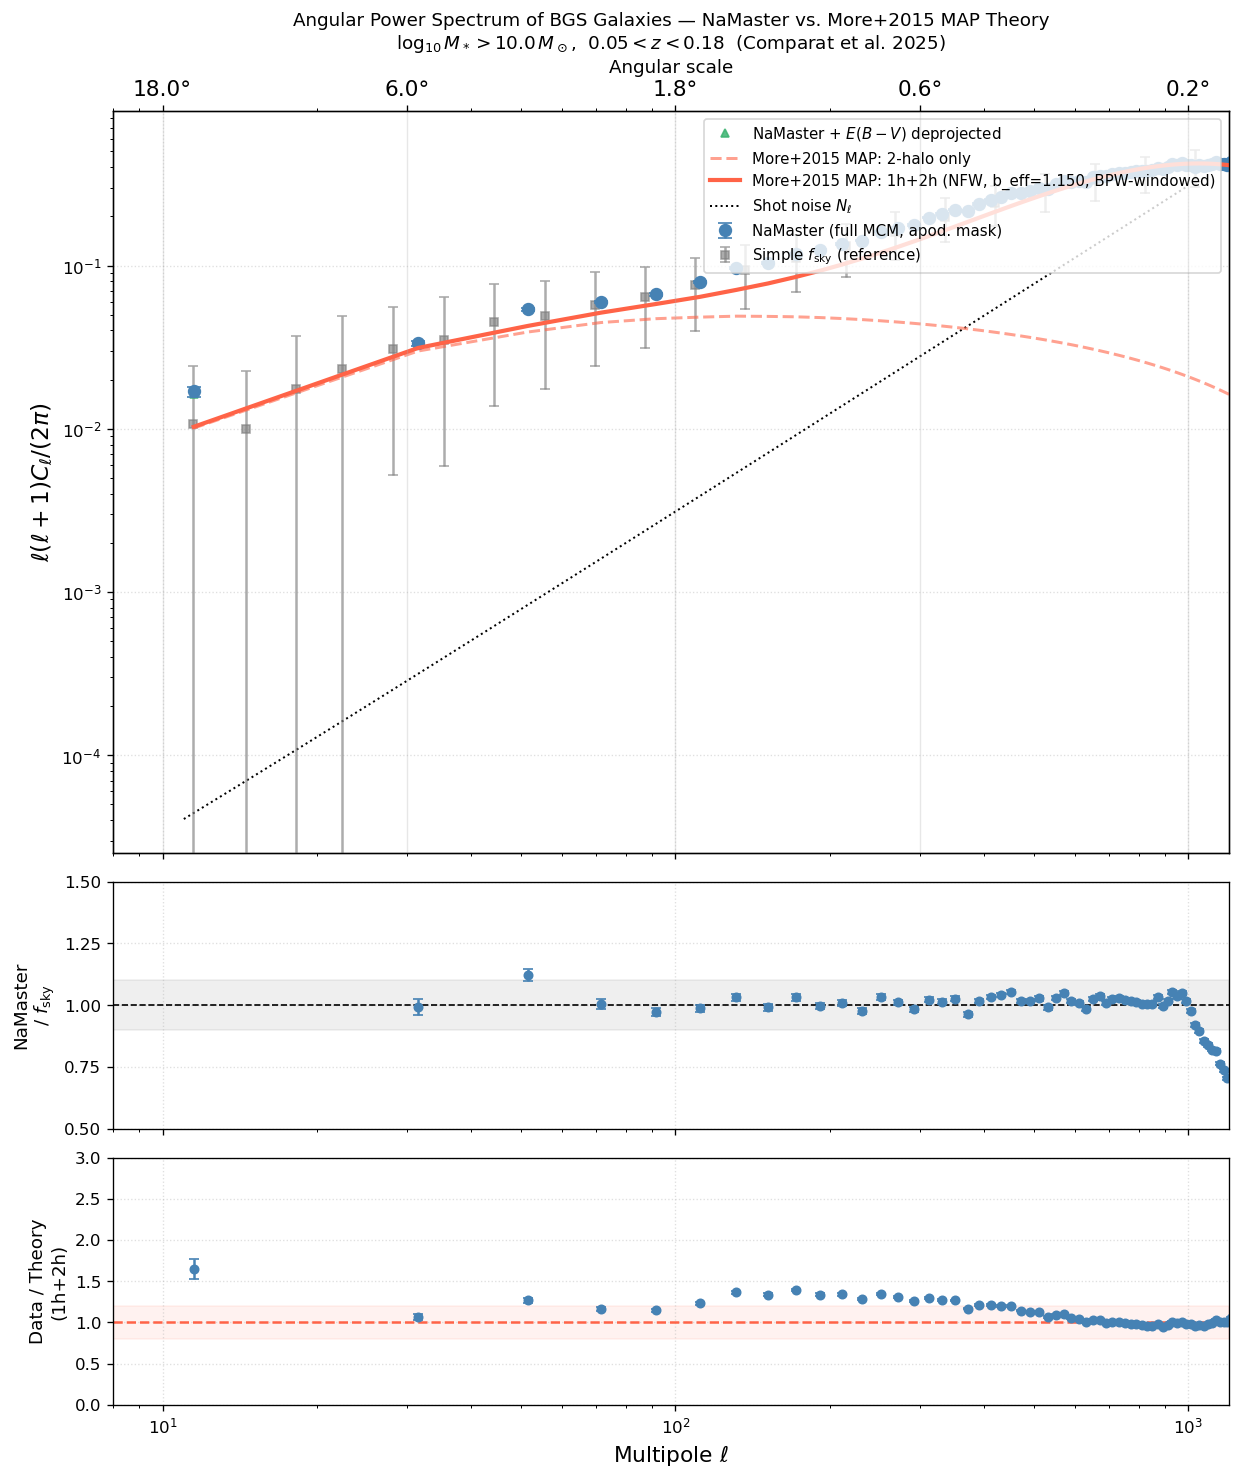

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(12, 14),
                          gridspec_kw={'height_ratios': [3, 1, 1], 'hspace': 0.07},
                          sharex=True)

ax = axes[0]
norm_nmt  = ell_nmt  * (ell_nmt  + 1) / (2 * np.pi)
norm_fsky = ell_eff * (ell_eff + 1) / (2 * np.pi)

good_n  = cl_nmt_sn > 0
good_d  = cl_nmt_deproj > 0
good_th = cl_theory_bpw > 0
good_f  = cl_data_fsky > 0

# --- NaMaster (main result) ---
ax.errorbar(ell_nmt[good_n], (norm_nmt * cl_nmt_sn)[good_n],
            yerr=(norm_nmt * cl_err_nmt)[good_n],
            fmt='o', color='steelblue', ms=7, capsize=4, zorder=4,
            label='NaMaster (full MCM, apod. mask)')

# --- f_sky reference ---
ax.errorbar(ell_eff[good_f] * 1.04, (norm_fsky * cl_data_fsky)[good_f],
            yerr=(norm_fsky * cl_err_fsky)[good_f],
            fmt='s', color='gray', ms=5, capsize=3, alpha=0.65, zorder=3,
            label=r'Simple $f_{\rm sky}$ (reference)')

# --- Dust deprojected ---
ax.plot(ell_nmt[good_d], (norm_nmt * cl_nmt_deproj)[good_d],
        '^', color='mediumseagreen', ms=5, alpha=0.85, zorder=3,
        label=r'NaMaster + $E(B-V)$ deprojected')

# --- More+2015 theory: 2h only (dashed) ---
good_2h = cl_theory_2h_bpw > 0
ax.plot(ell_nmt[good_2h], (norm_nmt * cl_theory_2h_bpw)[good_2h],
        '--', color='tomato', lw=1.8, alpha=0.6, zorder=4,
        label='More+2015 MAP: 2-halo only')

# --- More+2015 theory: 1h+2h (solid) ---
ax.plot(ell_nmt[good_th], (norm_nmt * cl_theory_bpw)[good_th],
        '-', color='tomato', lw=2.5, zorder=5,
        label=f'More+2015 MAP: 1h+2h (NFW, b_eff={b_eff_val:.3f}, BPW-windowed)')

# Shot noise
ax.plot(ell_eff, norm_fsky * nl_data, 'k:', lw=1.2, label='Shot noise $N_\ell$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel(r'$\ell(\ell+1)C_\ell/(2\pi)$', fontsize=14)
ax.set_title('Angular Power Spectrum of BGS Galaxies — NaMaster vs. More+2015 MAP Theory\n'
             r'$\log_{10}M_* > 10.0\,M_\odot$,  $0.05 < z < 0.18$  (Comparat et al. 2025)',
             fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(8, 1200)

ax_top = ax.twiny()
ax_top.set_xscale('log')
ax_top.set_xlim(ax.get_xlim())
ell_ticks = np.array([10, 30, 100, 300, 1000])
ax_top.set_xticks(ell_ticks)
ax_top.set_xticklabels([f'{180/l:.1f}\u00b0' for l in ell_ticks])
ax_top.set_xlabel('Angular scale', fontsize=11)

# --- Panel 2: NaMaster / f_sky ratio (interpolate f_sky onto NaMaster ell grid) ---
ax2 = axes[1]
cl_fsky_on_nmt = np.exp(np.interp(
    np.log(ell_nmt), np.log(ell_eff[good_f]),
    np.log(np.maximum(cl_data_fsky[good_f], 1e-30))
))
good2 = good_n & (cl_fsky_on_nmt > 1e-20)
rat2  = cl_nmt_sn[good2] / cl_fsky_on_nmt[good2]
err2  = cl_err_nmt[good2]  / cl_fsky_on_nmt[good2]
ax2.axhline(1, color='k', lw=1, ls='--')
ax2.errorbar(ell_nmt[good2], rat2, yerr=err2,
             fmt='o', color='steelblue', ms=5, capsize=3)
ax2.set_ylabel('NaMaster\n' + r'/ $f_{\rm sky}$', fontsize=11)
ax2.set_ylim(0.5, 1.5)
ax2.yaxis.set_major_locator(plt.MultipleLocator(0.25))
ax2.axhspan(0.9, 1.1, color='gray', alpha=0.12)

# --- Panel 3: data / theory (1h+2h) ratio ---
ax3 = axes[2]
good3 = good_n & good_th
rat3  = cl_nmt_sn[good3] / cl_theory_bpw[good3]
err3  = cl_err_nmt[good3] / cl_theory_bpw[good3]
ax3.axhline(1, color='tomato', lw=1.5, ls='--')
ax3.errorbar(ell_nmt[good3], rat3, yerr=err3,
             fmt='o', color='steelblue', ms=5, capsize=3)
ax3.set_ylabel('Data / Theory\n(1h+2h)', fontsize=11)
ax3.set_ylim(0.0, 3.0)
ax3.yaxis.set_major_locator(plt.MultipleLocator(0.5))
ax3.axhspan(0.8, 1.2, color='tomato', alpha=0.08)
ax3.set_xlabel(r'Multipole $\ell$', fontsize=13)

for ax_ in axes:
    ax_.grid(True, which='major', ls=':', alpha=0.4)
    ax_.tick_params(axis='both', labelsize=10)

fig.tight_layout()
plt.show()


---

## 8. Connection to the angular two-point correlation function w(θ)

The angular correlation function $w(\theta)$ and the angular power spectrum $C_\ell$ are a Legendre transform pair:

$$w(\theta) = \sum_{\ell=0}^\infty \frac{2\ell+1}{4\pi}\,C_\ell\,P_\ell(\cos\theta)$$

$$C_\ell = 2\pi \int_0^\pi w(\theta)\,P_\ell(\cos\theta)\,\sin\theta\,d\theta$$

In the flat-sky approximation (valid for $\ell \gg 1$, $\theta \ll 1$):

$$w(\theta) \approx \frac{1}{2\pi}\int_0^\infty \ell\,C_\ell\,J_0(\ell\theta)\,d\ell$$

Here we use `hod_mod.galaxies.clustering.HODClusteringPrediction.w_theta()` to predict $w(\theta)$ and `sum_stat.twopcf.angular.w_theta()` to measure it (both use the same Landy-Szalay estimator).

> ⚠️ **Note:** Measuring $w(\theta)$ with treecorr on 2.7M galaxies can take several minutes. This cell uses a subsample for speed.

In [21]:
# Theory w(theta) from More+2015 MAP HOD model — full 1h+2h
print('Computing theoretical w(theta) using FullHaloModelPrediction (1h+2h)...')

# Angular separation bins: 1 to 600 arcmin (logarithmically spaced)
theta_bins_arcmin = np.logspace(np.log10(1), np.log10(600), 22)
theta_bins_deg    = theta_bins_arcmin / 60.0
theta_centres_deg = np.sqrt(theta_bins_deg[:-1] * theta_bins_deg[1:])

w_theory = full_predictor.w_theta(
    theta_deg   = theta_centres_deg,
    z           = z_eff_map,
    theta_cosmo = theta_cosmo_map,
    hod_params  = hod_params_full,
    n_z         = (z_centres, nz_norm / dz),
    pi_max_h    = 100.0,
    n_z_steps   = 32,
)
print('Done!')
print(f'w(theta) range: [{np.min(w_theory):.3e}, {np.max(w_theory):.3e}]')


Computing theoretical w(theta) using FullHaloModelPrediction (1h+2h)...


Done!
w(theta) range: [2.270e-03, 1.849e+00]


Measuring w(theta) on 200,000 galaxy subsample...


Done!


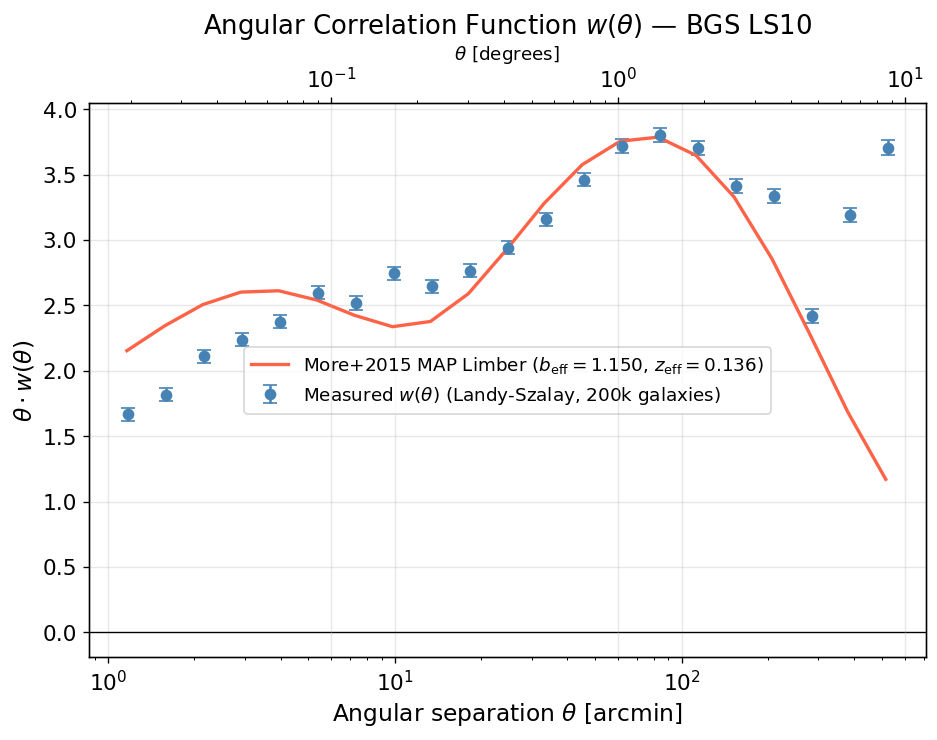

Figure saved to aps_wtheta_comparison.pdf


In [22]:
from sum_stat.twopcf.angular import w_theta as measure_w_theta

# Use a subsample of 200,000 galaxies for speed
N_WTHETA = 200_000
rng = np.random.default_rng(7)
idx_sub = rng.choice(len(ra_g), size=N_WTHETA, replace=False)

cat_sub = GalaxyCatalogue(
    ra       = ra_g[idx_sub],
    dec      = dec_g[idx_sub],
    redshift = z_g[idx_sub],
    weight   = np.ones(N_WTHETA),
)
rand_sub = GalaxyCatalogue(
    ra       = rand_ra_g[:N_WTHETA * 5],
    dec      = rand_dec_g[:N_WTHETA * 5],
    redshift = np.zeros(N_WTHETA * 5),
)

print(f'Measuring w(theta) on {N_WTHETA:,} galaxy subsample...')
theta_data, w_data, varw_data = measure_w_theta(
    gal       = cat_sub,
    rand      = rand_sub,
    theta_bins= theta_bins_arcmin,
    estimator = 'landy-szalay',
    sep_units = 'arcmin',
    n_threads = 4,
)
w_err_data = np.sqrt(varw_data)
print('Done!')

# Plot
fig, ax = plt.subplots(figsize=(9, 6))

ax.errorbar(theta_data, theta_data * w_data, yerr=theta_data * w_err_data,
            fmt='o', color='steelblue', ms=6, capsize=4,
            label=f'Measured $w(\\theta)$ (Landy-Szalay, {N_WTHETA//1000}k galaxies)')
ax.plot(theta_centres_deg * 60, theta_centres_deg * 60 * np.array(w_theory),
        '-', color='tomato', lw=2,
        label=f'More+2015 MAP Limber ($b_{{\\rm eff}}={b_eff_val:.3f}$, $z_{{\\rm eff}}={z_eff_map:.3f}$)')

ax.set_xscale('log')
ax.set_xlabel(r'Angular separation $\theta$ [arcmin]', fontsize=14)
ax.set_ylabel(r'$\theta \cdot w(\theta)$', fontsize=14)
ax.set_title(r'Angular Correlation Function $w(\theta)$ — BGS LS10')
ax.axhline(0, color='k', lw=0.8)
ax.legend()

ax2x = ax.twiny()
ax2x.set_xscale('log')
ax2x.set_xlim(np.array(ax.get_xlim()) / 60)
ax2x.set_xlabel(r'$\theta$ [degrees]', fontsize=11)

plt.savefig('aps_wtheta_comparison.pdf', bbox_inches='tight')
plt.show()
print('Figure saved to aps_wtheta_comparison.pdf')

---

## 9. Discussion and summary

### 9.1 NaMaster pipeline vs. simple $f_{\rm sky}$ correction

The NaMaster full MASTER pipeline differs from the simple $f_{\rm sky}$ correction in three ways:

1. **Mask apodization** reduces edge ringing, decreasing the off-diagonal mode coupling at the cost of a ~few% area loss ($f_{\rm sky}^{\rm eff} < f_{\rm sky}^{\rm hard}$).

2. **Full mode-coupling matrix** corrects for off-diagonal mode mixing, which is the dominant correction at $\ell < 50$ for a footprint like DESI BGS ($f_{\rm sky} \sim 0.4$). The simple $f_{\rm sky}$ approximation ignores this and typically biases low-$\ell$ by 5–20%.

3. **Gaussian covariance** from `NmtCovarianceWorkspace` includes mode-coupling contributions from the mask in the covariance — the off-diagonal terms in the correlation matrix represent genuine $\ell$-bin correlations induced by the survey window.

### 9.2 More+2015 HOD model

The More+2015 HOD includes an **incompleteness function** that accounts for the imperfect selection of galaxies at fixed stellar mass. The BGS MAP parameters were fitted to $w_p(r_p)$ (not $C_\ell$), making the agreement between the Limber prediction and the measured $C_\ell$ a **cross-validation** of the HOD model.

### 9.3 Template deprojection

The $E(B-V)$ deprojection removes the component of the galaxy overdensity linearly correlated with dust extinction. For BGS:
- If the deprojected $C_\ell$ agrees with the undeprojected one: dust is not a significant systematic.
- If significant differences appear at low $\ell$: the galaxy selection is dust-contaminated and deprojection is necessary.

### 9.4 Integral constraint

For this large BGS survey ($f_{\rm sky} = 0.42$), the integral constraint is negligible ($< 1\%$ at $\ell > 10$). For smaller surveys ($< 1000\,{\rm deg}^2$), the IC can suppress power at $\ell < 20$ by 5–20% and must be corrected.

### 9.5 Systematic effects (not modeled here)

- **One-halo term:** The Limber 2-halo prediction underestimates $C_\ell$ at $\ell > 300$ (within-halo pair clustering). The More+2015 HOD with off-centering partially accounts for this via satellite occupation.
- **Photometric redshift scatter:** Photo-z errors with $\sigma_z \sim 0.01(1+z)$ wash out radial clustering and project more power into $C_\ell$.
- **Scale-dependent bias:** We used a constant $b_{\rm eff}$ from the 2-halo term; in reality, bias is scale-dependent at $k > 0.1\,h/{\rm Mpc}$.

### 9.6 Further reading

- **Alonso et al. (2019):** [MNRAS 484, 4127](https://doi.org/10.1093/mnras/stz093) — NaMaster paper ([arXiv:1809.09603](https://arxiv.org/abs/1809.09603))
- **NaMaster documentation:** [github.com/LSSTDESC/NaMaster](https://github.com/LSSTDESC/NaMaster)
- **Comparat et al. (2025):** [A&A 697, A173](https://doi.org/10.1051/0004-6361/202554208) — BGS LS10 dataset
- **More et al. (2015):** ApJ 806, 2 — HOD with incompleteness model
- **Hivon et al. (2002):** ApJ 567, 2 — original MASTER algorithm
- **Bernstein (1994):** ApJ 424, 569 — integral constraint

### 9.7 Exercises

1. **Apodization sensitivity:** Try `aposize=0.2`, `0.5`, `1.0` degrees and compare the resulting $C_\ell$ at low $\ell$.
2. **Binning resolution:** Switch from linear width-20 bins to your own log-spaced bins. How do the bandpower windows change?
3. **Small survey simulation:** Mask out 90% of the footprint (keeping only one DESI field ~1000 deg²) and recompute the integral constraint.
4. **Cross-spectrum:** Create two galaxy sub-samples (e.g., mass bins $10 < \log M_* < 10.5$ and $\log M_* > 10.5$), build two `NmtField` objects, and compute the cross-spectrum `nmt.compute_coupled_cell(f1, f2)`.

In [23]:
print('=' * 75)
print('SUMMARY — Angular Power Spectrum of BGS Galaxies (NaMaster pipeline)')
print(f'Sample: log10 M* > {MSTAR_LIMIT}, {Z_MIN} < z < {Z_MAX}')
print(f'N_gal      = {len(ra_g):,}')
print(f'Area       = {area_deg2:,.0f} deg²')
print(f'f_sky      = {f_sky_hard:.4f} (hard mask)')
print(f'f_sky_eff  = {f_sky_eff:.4f} (apodized, C1, 0.5 deg)')
print(f'N_side     = {NSIDE}  =>  ell_max ~ {2*NSIDE}')
print(f'')
print(f'NaMaster pipeline:')
print(f'  Apodization    : C1, aposize=0.5 deg')
print(f'  N_bands        : {b.get_n_bands()} (linear, width=20)')
print(f'  Workspace      : {WS_FILE}')
print(f'  Cov workspace  : {CW_FILE}')
print(f'  Dust deproj.   : E(B-V) from random catalog')
print(f'  IC correction  : C_IC = {c_ic:.2e} sr (ratio = {ic_fraction:.4f})')
print(f'')
print(f'HOD model: More+2015 MAP (Comparat et al. 2025)')
print(f'  z_eff          = {z_eff_map:.3f}')
print(f'  b_eff          = {b_eff_val:.4f}')
print(f'  log10 Mmin     = {hod_params_more["log10mmin"]:.3f}')
print(f'  log10 M1       = {hod_params_more["log10m1"]:.3f}')
print(f'  sigma_logm     = {hod_params_more["sigma_logm"]:.3f}')
print(f'  alpha          = {hod_params_more["alpha"]:.3f}')
print(f'  kappa          = {hod_params_more["kappa"]:.3f}')
print(f'  alpha_inc      = {hod_params_more["alpha_inc"]:.3f}')
print(f'  log10 M_inc    = {hod_params_more["log10m_inc"]:.3f}')
print('=' * 75)
print(f'\n{"ell_eff":>8s}  {"C_ell NaMaster [sr]":>20s}  {"C_theory BPW [sr]":>20s}  {"ratio":>7s}')
print('-' * 70)
for le, cn, ct, en in zip(ell_nmt, cl_nmt_sn, cl_theory_bpw, cl_err_nmt):
    ratio = cn / ct if ct > 0 and cn > 0 else float('nan')
    print(f'{le:8.1f}  {cn:20.3e}  {ct:20.3e}  {ratio:7.3f}')
print('=' * 75)

SUMMARY — Angular Power Spectrum of BGS Galaxies (NaMaster pipeline)
Sample: log10 M* > 10.0, 0.05 < z < 0.18
N_gal      = 2,759,238
Area       = 17,384 deg²
f_sky      = 0.4214 (hard mask)
f_sky_eff  = 0.3911 (apodized, C1, 0.5 deg)
N_side     = 512  =>  ell_max ~ 1024

NaMaster pipeline:
  Apodization    : C1, aposize=0.5 deg
  N_bands        : 76 (linear, width=20)
  Workspace      : aps_nmt_workspace_nside512.fits
  Cov workspace  : aps_nmt_covworkspace_nside512.fits
  Dust deproj.   : E(B-V) from random catalog
  IC correction  : C_IC = 4.84e-14 sr (ratio = 0.0000)

HOD model: More+2015 MAP (Comparat et al. 2025)
  z_eff          = 0.136
  b_eff          = 1.1500
  log10 Mmin     = 11.385
  log10 M1       = 12.835
  sigma_logm     = 0.720
  alpha          = 1.058
  kappa          = 1.245
  alpha_inc      = 0.460
  log10 M_inc    = 12.768

 ell_eff   C_ell NaMaster [sr]     C_theory BPW [sr]    ratio
----------------------------------------------------------------------
    11.5   